<a href="https://colab.research.google.com/github/shrishtib07/SHRISHTI/blob/main/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

23BDS0158 — 1D, 2D & 3D Statistical Analysis + K-Means & Hierarchical Clustering



## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
DATA_URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/orange_juice_withmissing.csv"
df_raw = pd.read_csv(DATA_URL)
df = df_raw.copy()
print("Shape:", df.shape)
df.head()

Shape: (1070, 18)


,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1.0000,1.7500,1.9900,0.0000,0.0000,0.0000,0.0000,0.5000,1.9900,1.7500,0.2400,No,0.0000,0.0000,0.2400,1.0000
1,CH,239,1.0000,1.7500,1.9900,0.0000,0.3000,0.0000,1.0000,0.6000,1.6900,1.7500,-0.0600,No,0.1508,0.0000,0.2400,1.0000
2,CH,245,1.0000,1.8600,2.0900,0.1700,0.0000,0.0000,0.0000,0.6800,2.0900,1.6900,0.4000,No,0.0000,0.0914,0.2300,1.0000
3,MM,227,1.0000,1.6900,1.6900,0.0000,0.0000,0.0000,0.0000,0.4000,1.6900,1.6900,0.0000,No,0.0000,0.0000,0.0000,1.0000
4,CH,228,7.0000,1.6900,1.6900,0.0000,0.0000,0.0000,0.0000,0.9565,1.6900,1.6900,0.0000,Yes,0.0000,0.0000,0.0000,0.0000


## 2. Data Inspection & Missing-Value Treatment

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   object 
 1   WeekofPurchase  1070 non-null   int64  
 2   StoreID         1069 non-null   float64
 3   PriceCH         1069 non-null   float64
 4   PriceMM         1066 non-null   float64
 5   DiscCH          1068 non-null   float64
 6   DiscMM          1066 non-null   float64
 7   SpecialCH       1068 non-null   float64
 8   SpecialMM       1065 non-null   float64
 9   LoyalCH         1065 non-null   float64
 10  SalePriceMM     1065 non-null   float64
 11  SalePriceCH     1069 non-null   float64
 12  PriceDiff       1069 non-null   float64
 13  Store7          1070 non-null   object 
 14  PctDiscMM       1065 non-null   float64
 15  PctDiscCH       1068 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1068 non-null   f

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Purchase,1070,2,CH,653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WeekofPurchase,"1,070.0000",NaN,NaN,NaN,254.3813,15.5583,227.0000,240.0000,257.0000,268.0000,278.0000
StoreID,"1,069.0000",NaN,NaN,NaN,3.9570,2.3082,1.0000,2.0000,3.0000,7.0000,7.0000
PriceCH,"1,069.0000",NaN,NaN,NaN,1.8674,0.1020,1.6900,1.7900,1.8600,1.9900,2.0900
PriceMM,"1,066.0000",NaN,NaN,NaN,2.0850,0.1344,1.6900,1.9900,2.0900,2.1800,2.2900
DiscCH,"1,068.0000",NaN,NaN,NaN,0.0520,0.1176,0.0000,0.0000,0.0000,0.0000,0.5000
DiscMM,"1,066.0000",NaN,NaN,NaN,0.1234,0.2141,0.0000,0.0000,0.0000,0.2300,0.8000
SpecialCH,"1,068.0000",NaN,NaN,NaN,0.1470,0.3543,0.0000,0.0000,0.0000,0.0000,1.0000
SpecialMM,"1,065.0000",NaN,NaN,NaN,0.1624,0.3690,0.0000,0.0000,0.0000,0.0000,1.0000
LoyalCH,"1,065.0000",NaN,NaN,NaN,0.5652,0.3081,0.0000,0.3200,0.6000,0.8506,0.9999


In [5]:
# Missing value summary
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
print("Total missing cells:", int(df.isna().sum().sum()))
print("Rows with at least one missing value:", int(df.isna().any(axis=1).sum()))
missing[missing.missing_count > 0]

Total missing cells: 40
Rows with at least one missing value: 38


,missing_count,missing_pct
LoyalCH,5,0.4700
SpecialMM,5,0.4700
PctDiscMM,5,0.4700
SalePriceMM,5,0.4700
PriceMM,4,0.3700
DiscMM,4,0.3700
PctDiscCH,2,0.1900
STORE,2,0.1900
DiscCH,2,0.1900
SpecialCH,2,0.1900


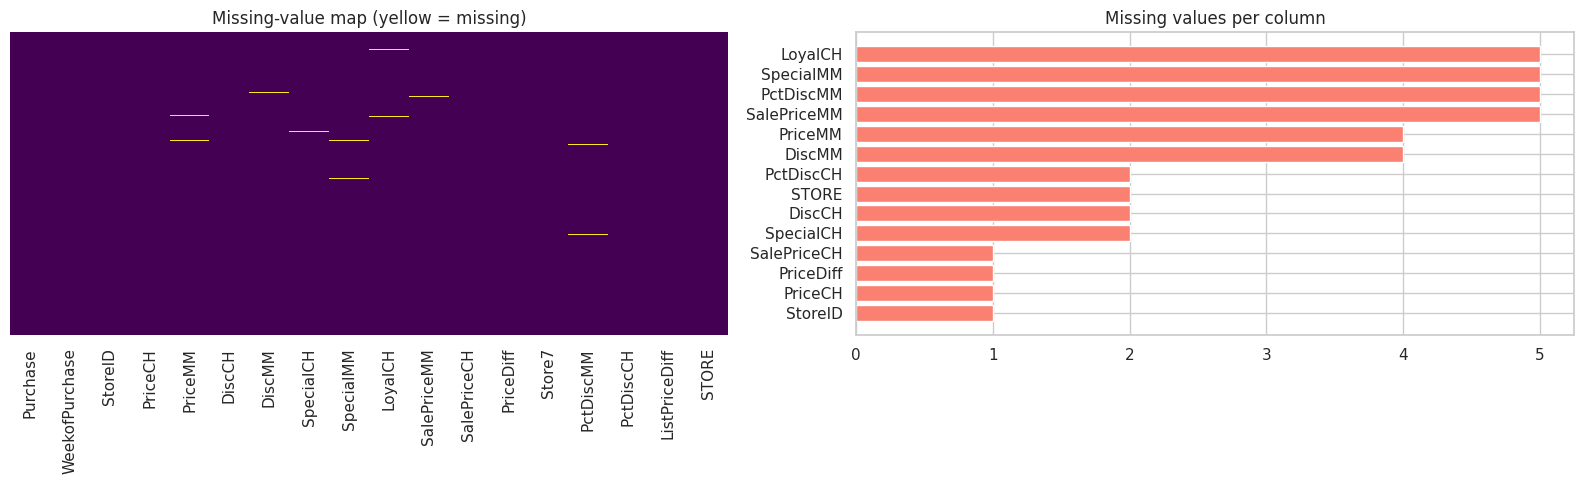

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Missing-value map (yellow = missing)")
m = missing[missing.missing_count > 0]
axes[1].barh(m.index, m.missing_count, color="salmon")
axes[1].set_title("Missing values per column")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

In [7]:
categorical_cols = ["Purchase", "Store7", "StoreID", "STORE", "SpecialCH", "SpecialMM"]
numeric_cols = [c for c in df.columns if c not in categorical_cols]

for c in categorical_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())

# Consistent dtypes
for c in ["StoreID", "STORE", "SpecialCH", "SpecialMM"]:
    df[c] = df[c].astype(int)
df["WeekofPurchase"] = df["WeekofPurchase"].astype(int)

# Encoded helper columns
df["Purchase_bin"] = (df["Purchase"] == "MM").astype(int)   # 1 = MM, 0 = CH
df["Store7_bin"]   = (df["Store7"] == "Yes").astype(int)

print("Missing after imputation:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Missing after imputation: 0
Duplicate rows: 25


In [8]:
continuous = ["WeekofPurchase", "PriceCH", "PriceMM", "DiscCH", "DiscMM", "LoyalCH",
              "SalePriceMM", "SalePriceCH", "PriceDiff", "PctDiscMM", "PctDiscCH", "ListPriceDiff"]
discrete = ["Purchase", "StoreID", "Store7", "SpecialCH", "SpecialMM", "STORE"]

## 3. 1D (Univariate) Statistical Analysis


In [9]:
def univariate_summary(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return pd.Series({
        "count": s.count(), "mean": s.mean(), "median": s.median(),
        "mode": s.mode().iloc[0], "min": s.min(), "max": s.max(),
        "range": s.max() - s.min(), "Q1": q1, "Q3": q3, "IQR": q3 - q1,
        "variance": s.var(), "std": s.std(), "sem": s.sem(),
        "CV_%": (s.std() / s.mean() * 100) if s.mean() != 0 else np.nan,
        "skewness": s.skew(), "kurtosis": s.kurt(),
    })

uni = df[continuous].apply(univariate_summary).T
uni

,count,mean,median,mode,min,max,range,Q1,Q3,IQR,variance,std,sem,CV_%,skewness,kurtosis
WeekofPurchase,"1,070.0000",254.3813,257.0000,274.0000,227.0000,278.0000,51.0000,240.0000,268.0000,28.0000,242.0603,15.5583,0.4756,6.1161,-0.2110,-1.2749
PriceCH,"1,070.0000",1.8674,1.8600,1.8600,1.6900,2.0900,0.4000,1.7900,1.9900,0.2000,0.0104,0.1020,0.0031,5.4605,0.0644,-0.7751
PriceMM,"1,070.0000",2.0851,2.0900,2.0900,1.6900,2.2900,0.6000,1.9900,2.1800,0.1900,0.0180,0.1342,0.0041,6.4352,-1.4647,2.1951
DiscCH,"1,070.0000",0.0519,0.0000,0.0000,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0138,0.1175,0.0036,226.5226,2.4163,4.9336
DiscMM,"1,070.0000",0.1230,0.0000,0.0000,0.0000,0.8000,0.8000,0.0000,0.2000,0.2000,0.0457,0.2139,0.0065,173.9338,1.5995,1.5026
LoyalCH,"1,070.0000",0.5654,0.6000,0.5000,0.0000,0.9999,0.9999,0.3253,0.8506,0.5253,0.0945,0.3074,0.0094,54.3645,-0.2800,-1.0543
SalePriceMM,"1,070.0000",1.9625,2.0900,2.0900,1.1900,2.2900,1.1000,1.6900,2.1300,0.4400,0.0635,0.2521,0.0077,12.8441,-0.8076,-0.4970
SalePriceCH,"1,070.0000",1.8156,1.8600,1.8600,1.3900,2.0900,0.7000,1.7500,1.8900,0.1400,0.0206,0.1434,0.0044,7.8975,-0.9527,0.9598
PriceDiff,"1,070.0000",0.1464,0.2300,0.3000,-0.6700,0.6400,1.3100,0.0000,0.3200,0.3200,0.0737,0.2715,0.0083,185.4640,-0.7594,0.4669
PctDiscMM,"1,070.0000",0.0591,0.0000,0.0000,0.0000,0.4020,0.4020,0.0000,0.1127,0.1127,0.0103,0.1017,0.0031,172.0228,1.5458,1.2935


In [10]:
# Interpretation of shape
shape = pd.DataFrame({
    "skewness": uni["skewness"],
    "skew_type": np.select([uni["skewness"] > 0.5, uni["skewness"] < -0.5],
                           ["Right (positive) skewed", "Left (negative) skewed"],
                           "Approximately symmetric"),
    "kurtosis": uni["kurtosis"],
    "kurtosis_type": np.select([uni["kurtosis"] > 0.5, uni["kurtosis"] < -0.5],
                               ["Leptokurtic (heavy tails)", "Platykurtic (light tails)"],
                               "Mesokurtic (~normal)"),
})
shape

,skewness,skew_type,kurtosis,kurtosis_type
WeekofPurchase,-0.2110,Approximately symmetric,-1.2749,Platykurtic (light tails)
PriceCH,0.0644,Approximately symmetric,-0.7751,Platykurtic (light tails)
PriceMM,-1.4647,Left (negative) skewed,2.1951,Leptokurtic (heavy tails)
DiscCH,2.4163,Right (positive) skewed,4.9336,Leptokurtic (heavy tails)
DiscMM,1.5995,Right (positive) skewed,1.5026,Leptokurtic (heavy tails)
LoyalCH,-0.2800,Approximately symmetric,-1.0543,Platykurtic (light tails)
SalePriceMM,-0.8076,Left (negative) skewed,-0.4970,Mesokurtic (~normal)
SalePriceCH,-0.9527,Left (negative) skewed,0.9598,Leptokurtic (heavy tails)
PriceDiff,-0.7594,Left (negative) skewed,0.4669,Mesokurtic (~normal)
PctDiscMM,1.5458,Right (positive) skewed,1.2935,Leptokurtic (heavy tails)


In [11]:
for c in discrete:
    ft = pd.DataFrame({"count": df[c].value_counts(),
                       "percent": (df[c].value_counts(normalize=True) * 100).round(2)})
    print(f"\n===== {c} =====")
    print(ft)


===== Purchase =====
          count  percent
Purchase                
CH          653  61.0300
MM          417  38.9700

===== StoreID =====
         count  percent
StoreID                
7          356  33.2700
2          222  20.7500
3          196  18.3200
1          157  14.6700
4          139  12.9900

===== Store7 =====
        count  percent
Store7                
No        714  66.7300
Yes       356  33.2700

===== SpecialCH =====
           count  percent
SpecialCH                
0            913  85.3300
1            157  14.6700

===== SpecialMM =====
           count  percent
SpecialMM                
0            897  83.8300
1            173  16.1700

===== STORE =====
       count  percent
STORE                
0        358  33.4600
2        222  20.7500
3        194  18.1300
1        157  14.6700
4        139  12.9900


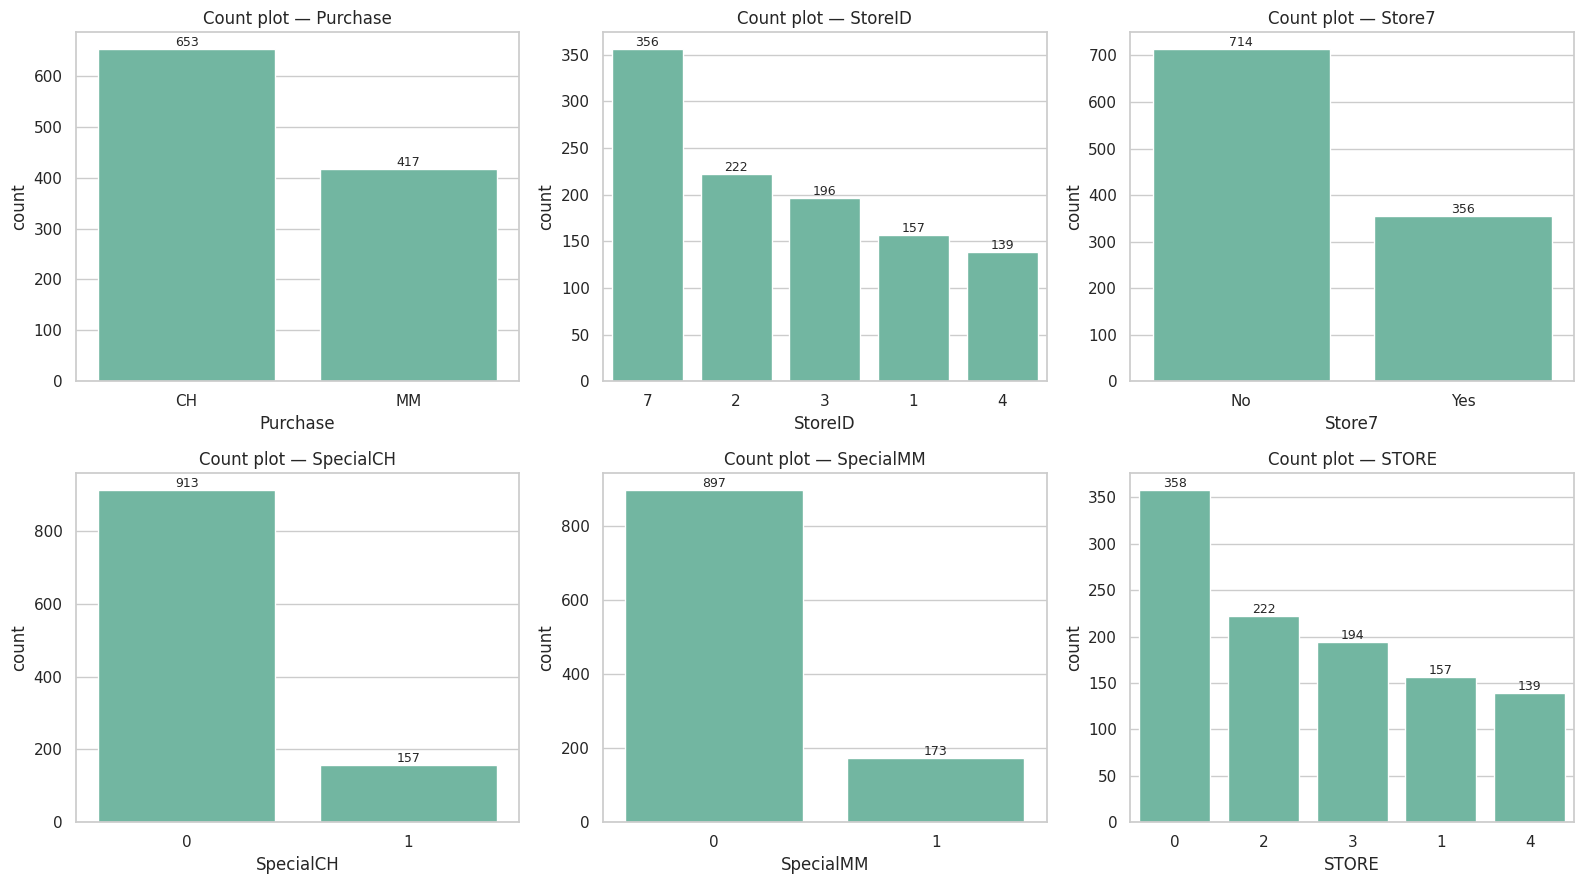

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.ravel(), discrete):
    order = df[c].value_counts().index
    sns.countplot(x=c, data=df, order=order, ax=ax)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Count plot — {c}")
plt.tight_layout(); plt.show()

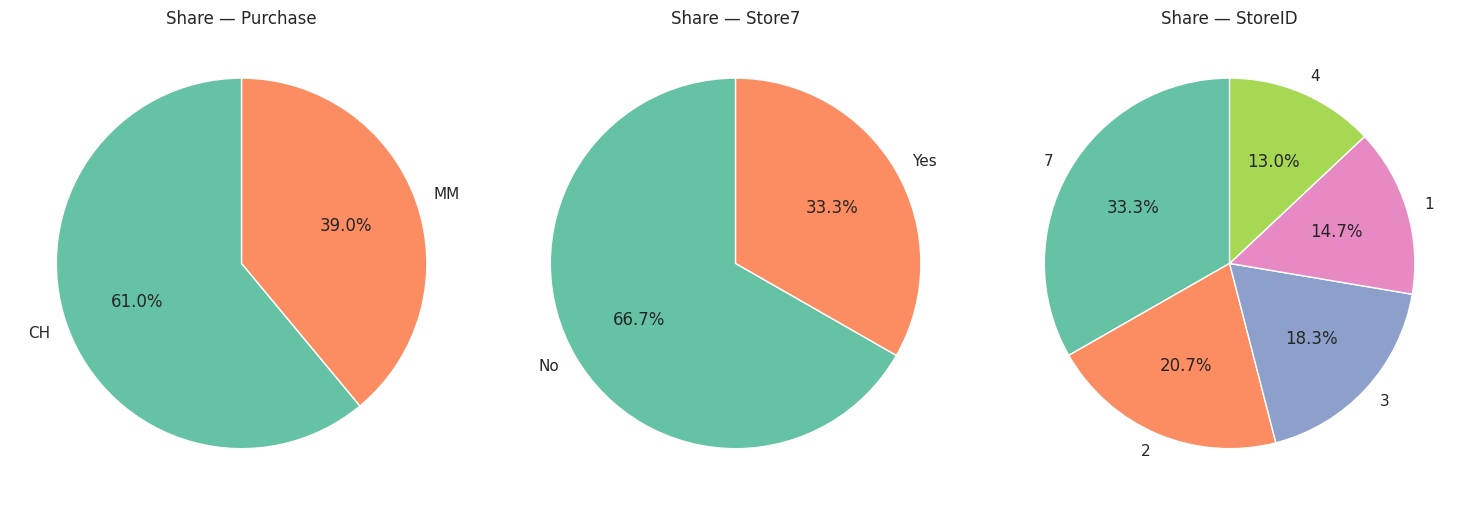

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, ["Purchase", "Store7", "StoreID"]):
    df[c].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=ax)
    ax.set_ylabel(""); ax.set_title(f"Share — {c}")
plt.tight_layout(); plt.show()

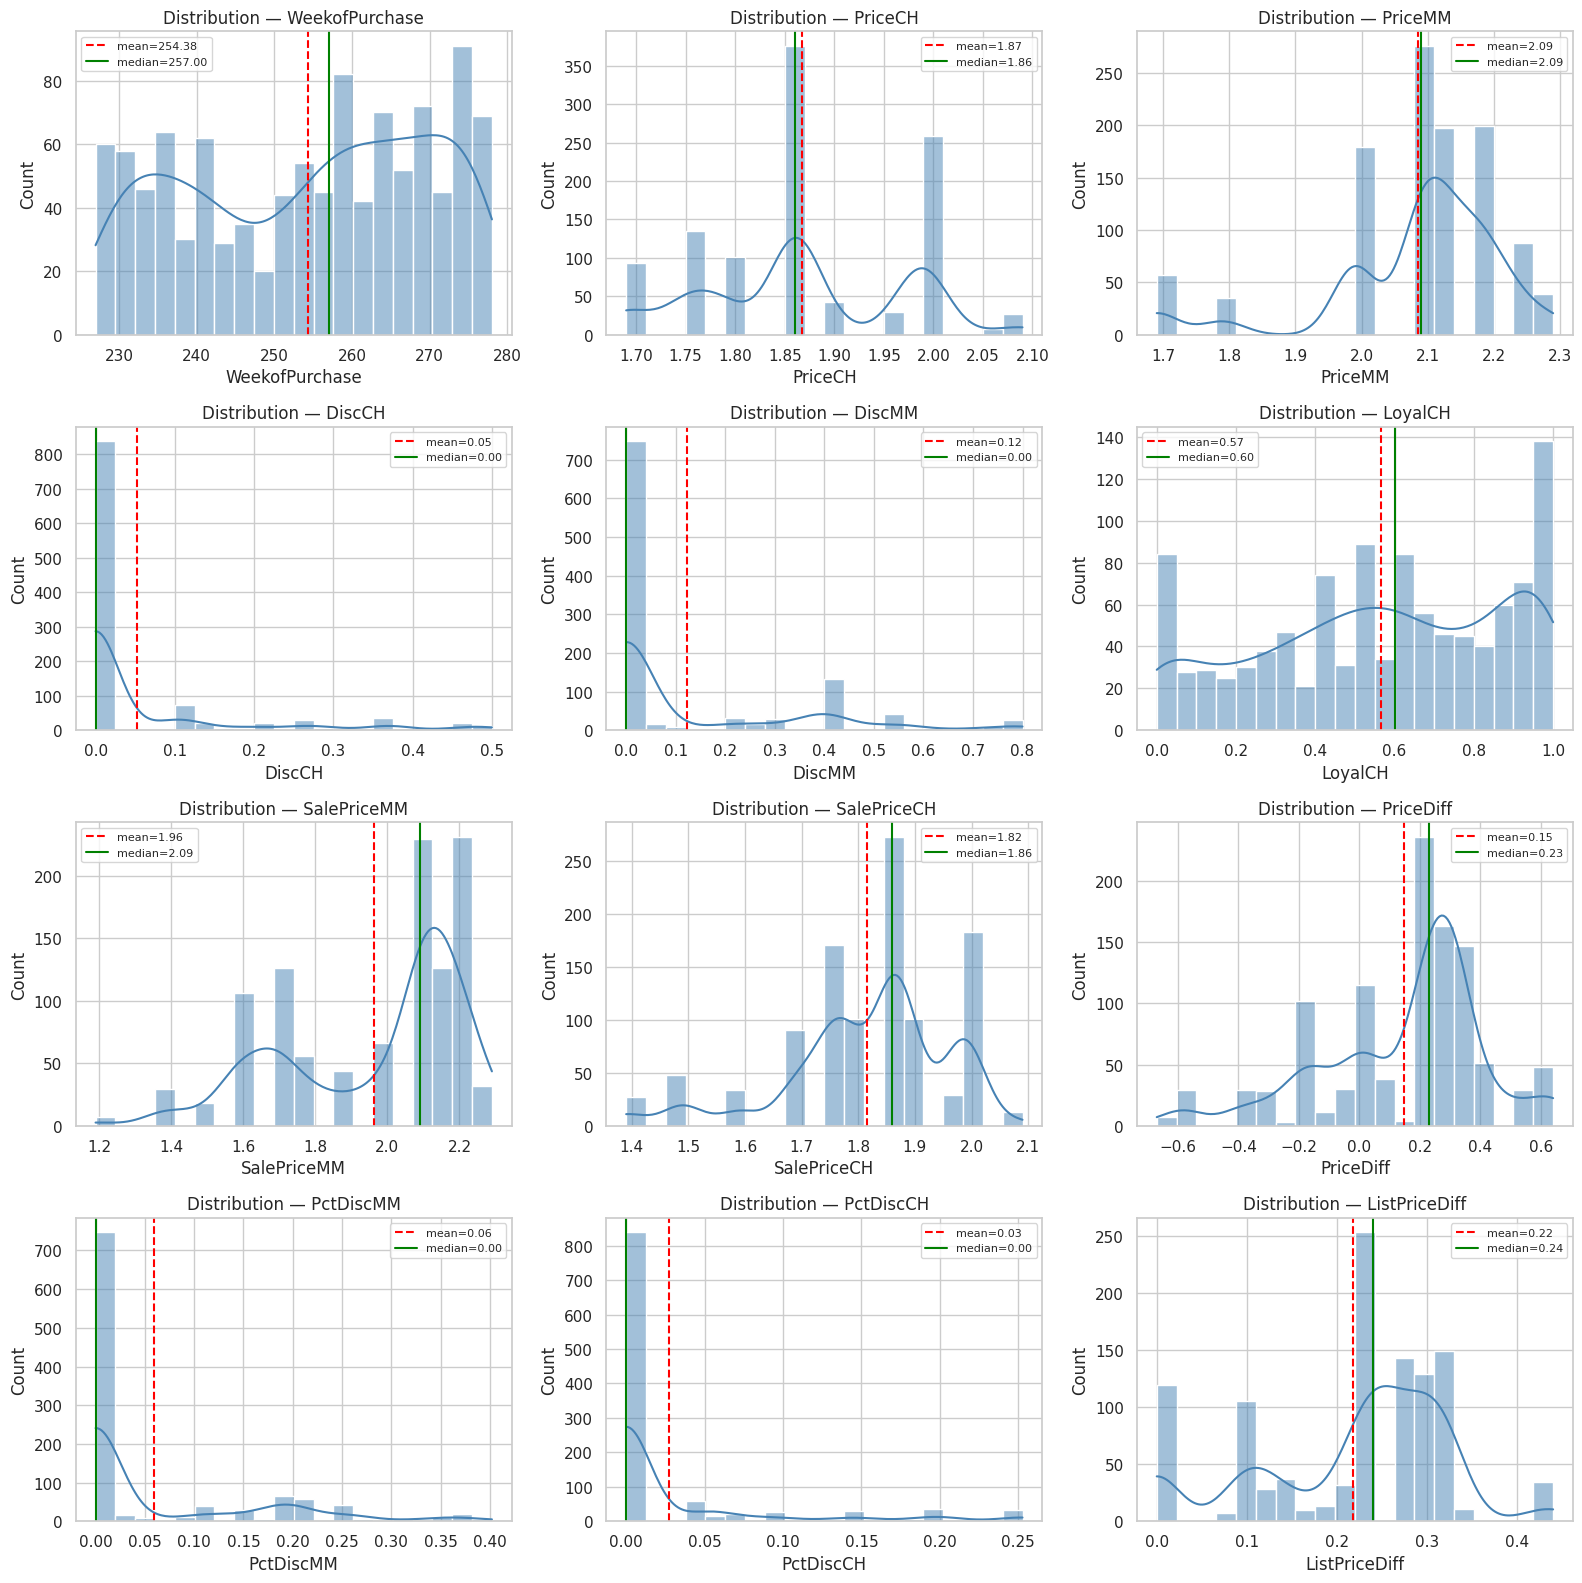

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, c in zip(axes.ravel(), continuous):
    sns.histplot(df[c], kde=True, bins=20, ax=ax, color="steelblue")
    ax.axvline(df[c].mean(), color="red", ls="--", label=f"mean={df[c].mean():.2f}")
    ax.axvline(df[c].median(), color="green", ls="-", label=f"median={df[c].median():.2f}")
    ax.legend(fontsize=8); ax.set_title(f"Distribution — {c}")
plt.tight_layout(); plt.show()

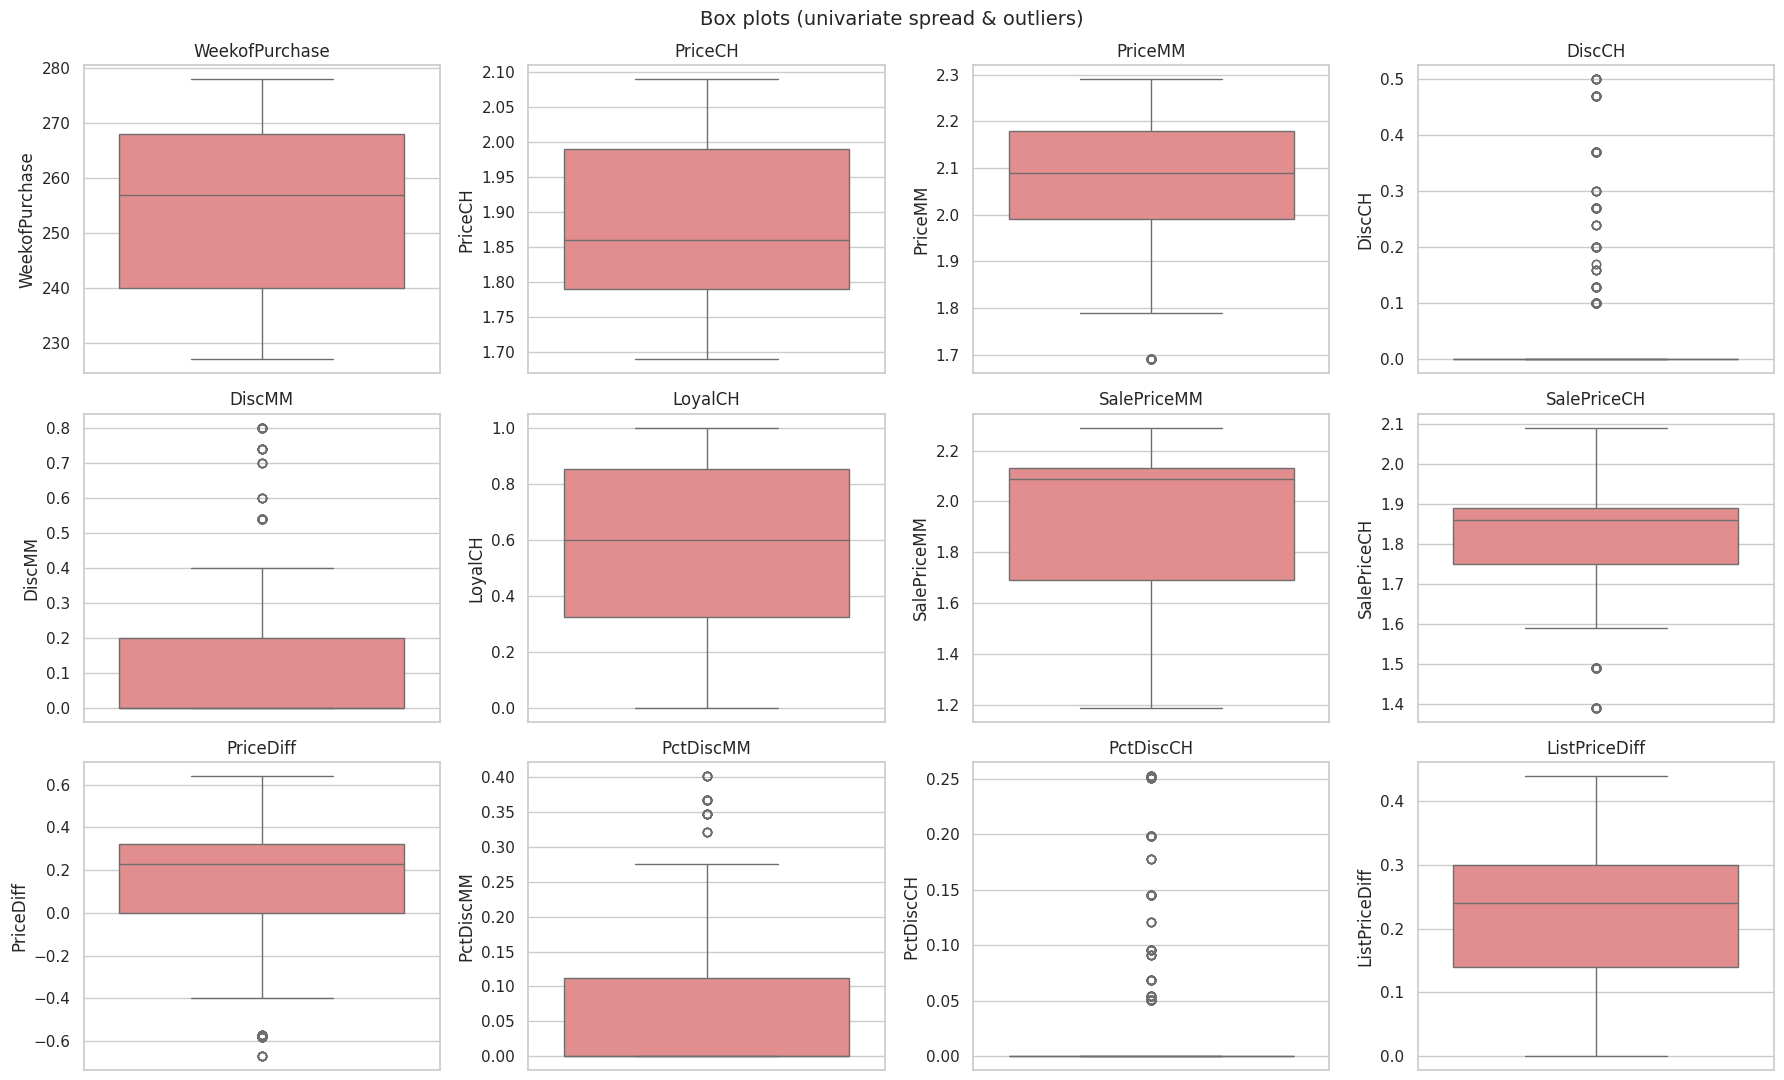

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, c in zip(axes.ravel(), continuous):
    sns.boxplot(y=df[c], ax=ax, color="lightcoral")
    ax.set_title(c)
plt.suptitle("Box plots (univariate spread & outliers)", fontsize=14)
plt.tight_layout(); plt.show()

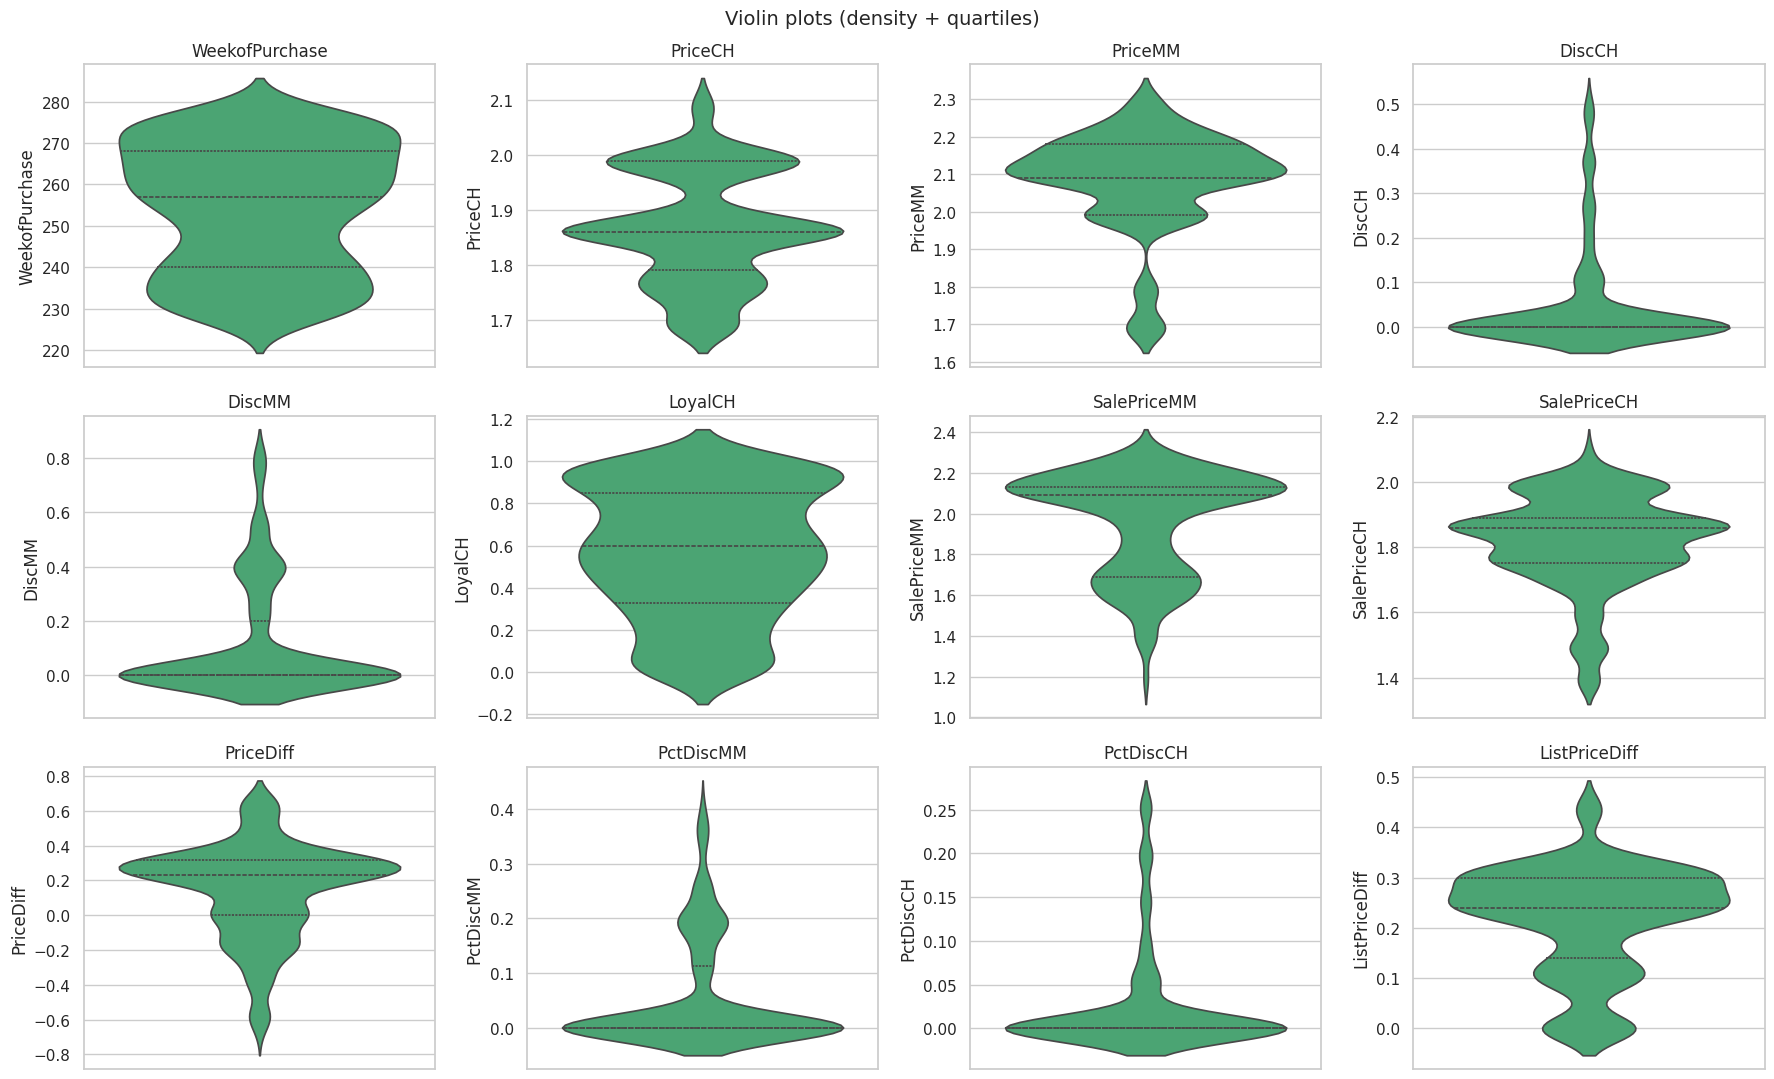

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, c in zip(axes.ravel(), continuous):
    sns.violinplot(y=df[c], ax=ax, color="mediumseagreen", inner="quartile")
    ax.set_title(c)
plt.suptitle("Violin plots (density + quartiles)", fontsize=14)
plt.tight_layout(); plt.show()

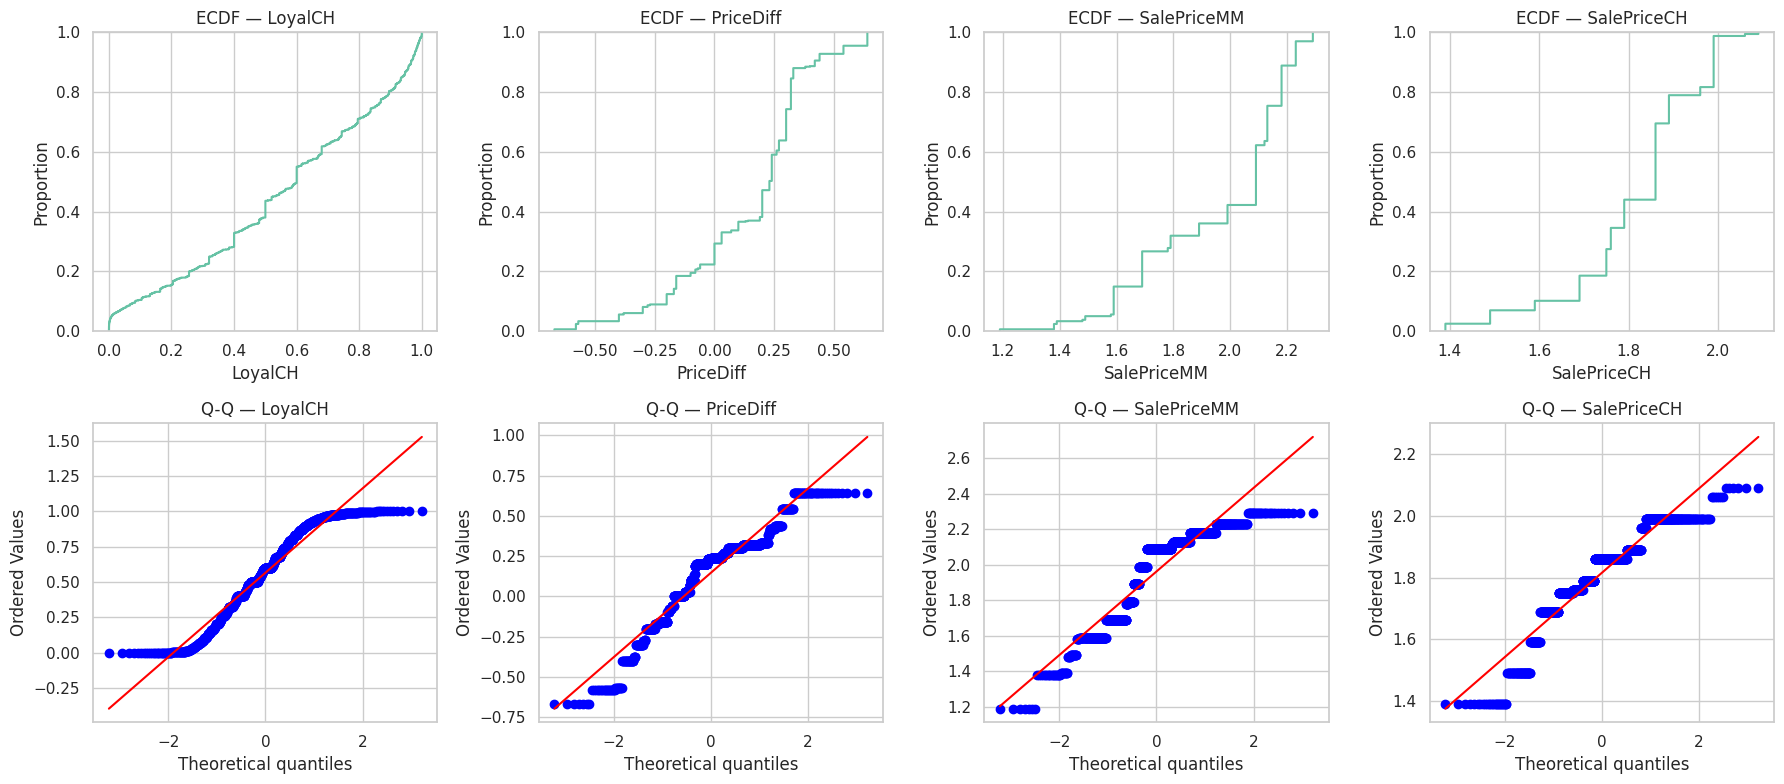

In [17]:
key_vars = ["LoyalCH", "PriceDiff", "SalePriceMM", "SalePriceCH"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, c in enumerate(key_vars):
    sns.ecdfplot(df[c], ax=axes[0, i]); axes[0, i].set_title(f"ECDF — {c}")
    stats.probplot(df[c], dist="norm", plot=axes[1, i]); axes[1, i].set_title(f"Q-Q — {c}")
plt.tight_layout(); plt.show()

In [18]:
rows = []
for c in continuous:
    x = df[c]
    sh_stat, sh_p = stats.shapiro(x.sample(min(len(x), 5000), random_state=RANDOM_STATE))
    dp_stat, dp_p = stats.normaltest(x)
    ad = stats.anderson(x, dist="norm")
    rows.append({"variable": c,
                 "Shapiro_W": sh_stat, "Shapiro_p": sh_p,
                 "DAgostino_K2": dp_stat, "DAgostino_p": dp_p,
                 "Anderson_stat": ad.statistic, "Anderson_crit_5%": ad.critical_values[2],
                 "Normal @5%?": "Yes" if sh_p > 0.05 else "No"})
pd.DataFrame(rows).set_index("variable")

,Shapiro_W,Shapiro_p,DAgostino_K2,DAgostino_p,Anderson_stat,Anderson_crit_5%,Normal @5%?
variable,,,,,,,
WeekofPurchase,0.9346,0.0000,"1,666.6511",0.0000,20.5440,0.7840,No
PriceCH,0.9181,0.0000,78.9498,0.0000,37.5649,0.7840,No
PriceMM,0.8329,0.0000,278.2316,0.0000,58.1294,0.7840,No
DiscCH,0.5071,0.0000,519.5185,0.0000,238.3343,0.7840,No
DiscMM,0.6283,0.0000,283.8281,0.0000,184.7738,0.7840,No
LoyalCH,0.9405,0.0000,321.7065,0.0000,14.8842,0.7840,No
SalePriceMM,0.8707,0.0000,111.7656,0.0000,59.6370,0.7840,No
SalePriceCH,0.9075,0.0000,140.3820,0.0000,29.9677,0.7840,No
PriceDiff,0.9299,0.0000,90.4031,0.0000,30.3409,0.7840,No


In [19]:
out = []
for c in continuous:
    q1, q3 = df[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = np.abs(stats.zscore(df[c]))
    out.append({"variable": c, "lower_fence": lo, "upper_fence": hi,
                "IQR_outliers": int(((df[c] < lo) | (df[c] > hi)).sum()),
                "Z>3_outliers": int((z > 3).sum())})
pd.DataFrame(out).set_index("variable")

,lower_fence,upper_fence,IQR_outliers,Z>3_outliers
variable,,,,
WeekofPurchase,198.0000,310.0000,0,0
PriceCH,1.4900,2.2900,0,0
PriceMM,1.7050,2.4650,57,0
DiscCH,0.0000,0.0000,232,33
DiscMM,-0.3000,0.5000,89,26
LoyalCH,-0.4627,1.6386,0,0
SalePriceMM,1.0300,2.7900,0,7
SalePriceCH,1.5400,2.1000,75,0
PriceDiff,-0.4800,0.8000,36,7


## 4. 2D (Bivariate) Statistical Analysis


In [20]:
num_for_corr = continuous + ["Purchase_bin", "Store7_bin", "SpecialCH", "SpecialMM"]
cov = df[continuous].cov()
cov

,WeekofPurchase,PriceCH,PriceMM,DiscCH,DiscMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff
WeekofPurchase,242.0603,1.1174,1.2031,0.6684,0.8069,0.9198,0.4125,0.4490,-0.0500,0.3525,0.3430,0.0887
PriceCH,1.1174,0.0104,0.0084,0.0018,0.0025,0.0024,0.0059,0.0086,-0.0027,0.0010,0.0008,-0.0020
PriceMM,1.2031,0.0084,0.0180,0.0010,-0.0001,0.0048,0.0180,0.0074,0.0107,-0.0003,0.0005,0.0096
DiscCH,0.6684,0.0018,0.0010,0.0138,0.0005,0.0051,0.0006,-0.0120,0.0126,0.0002,0.0073,-0.0008
DiscMM,0.8069,0.0025,-0.0001,0.0005,0.0457,-0.0014,-0.0455,0.0021,-0.0478,0.0217,0.0003,-0.0026
LoyalCH,0.9198,0.0024,0.0048,0.0051,-0.0014,0.0945,0.0060,-0.0027,0.0088,-0.0007,0.0026,0.0024
SalePriceMM,0.4125,0.0059,0.0180,0.0006,-0.0455,0.0060,0.0635,0.0053,0.0582,-0.0218,0.0003,0.0121
SalePriceCH,0.4490,0.0086,0.0074,-0.0120,0.0021,-0.0027,0.0053,0.0206,-0.0152,0.0009,-0.0065,-0.0012
PriceDiff,-0.0500,-0.0027,0.0107,0.0126,-0.0478,0.0088,0.0582,-0.0152,0.0737,-0.0228,0.0067,0.0133
PctDiscMM,0.3525,0.0010,-0.0003,0.0002,0.0217,-0.0007,-0.0218,0.0009,-0.0228,0.0103,0.0001,-0.0013


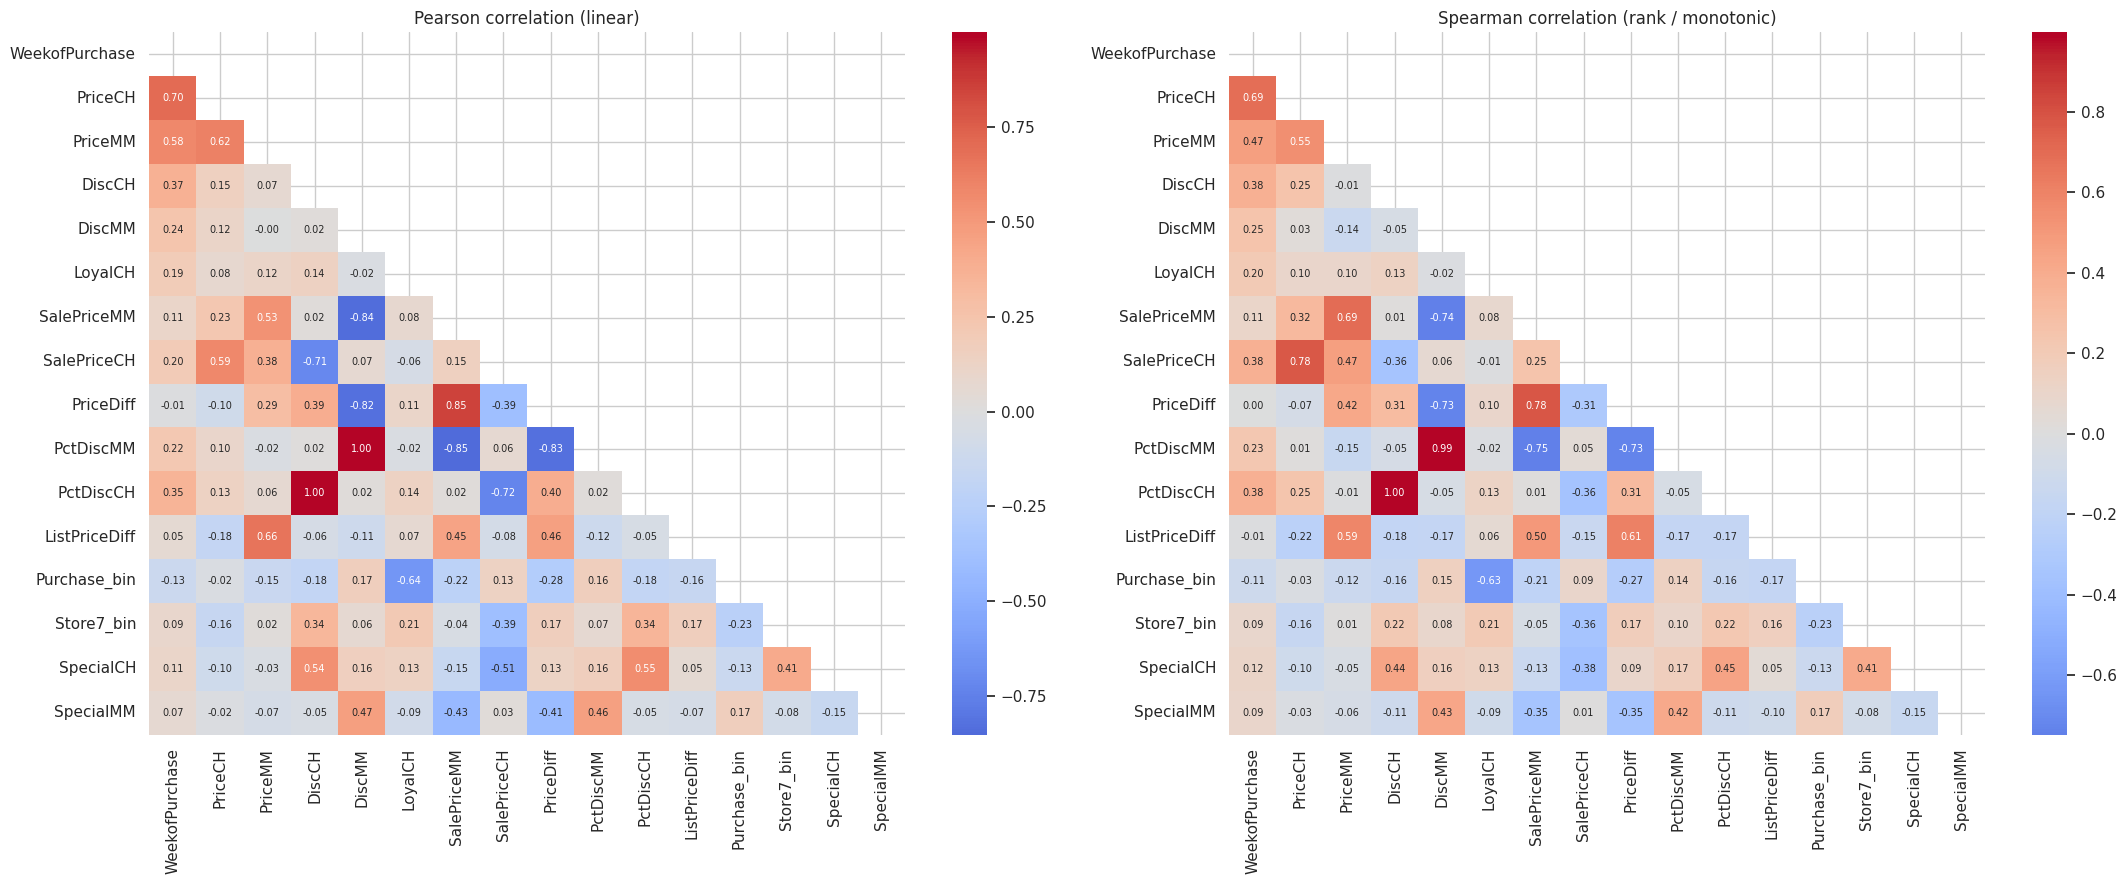

In [21]:
pearson = df[num_for_corr].corr(method="pearson")
spearman = df[num_for_corr].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
mask = np.triu(np.ones_like(pearson, dtype=bool))
sns.heatmap(pearson, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Pearson correlation (linear)")
sns.heatmap(spearman, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Spearman correlation (rank / monotonic)")
plt.tight_layout(); plt.show()

In [22]:
# Strongest pairwise correlations (absolute Pearson)
pairs = (pearson.where(np.triu(np.ones(pearson.shape), k=1).astype(bool))
         .stack().rename("pearson_r").to_frame())
pairs["abs_r"] = pairs["pearson_r"].abs()
pairs.sort_values("abs_r", ascending=False).head(15)

pearson_r  abs_r
DiscCH         PctDiscCH         0.9987 0.9987
DiscMM         PctDiscMM         0.9962 0.9962
SalePriceMM    PctDiscMM        -0.8515 0.8515
               PriceDiff         0.8499 0.8499
DiscMM         SalePriceMM      -0.8432 0.8432
PriceDiff      PctDiscMM        -0.8265 0.8265
DiscMM         PriceDiff        -0.8229 0.8229
SalePriceCH    PctDiscCH        -0.7231 0.7231
DiscCH         SalePriceCH      -0.7113 0.7113
WeekofPurchase PriceCH           0.7043 0.7043
PriceMM        ListPriceDiff     0.6645 0.6645
LoyalCH        Purchase_bin     -0.6404 0.6404
PriceCH        PriceMM           0.6152 0.6152
               SalePriceCH       0.5867 0.5867
WeekofPurchase PriceMM           0.5763 0.5763

In [23]:
# Significance of correlations with the target (MM purchase)
rows = []
for c in continuous:
    r, p = stats.pearsonr(df[c], df["Purchase_bin"])
    rho, p_s = stats.spearmanr(df[c], df["Purchase_bin"])
    rows.append({"variable": c, "pearson_r": r, "p_value": p, "spearman_rho": rho, "p_spearman": p_s})
pd.DataFrame(rows).set_index("variable").sort_values("pearson_r", key=abs, ascending=False)

,pearson_r,p_value,spearman_rho,p_spearman
variable,,,,
LoyalCH,-0.6404,0.0000,-0.6318,0.0000
PriceDiff,-0.2755,0.0000,-0.2656,0.0000
SalePriceMM,-0.2184,0.0000,-0.2053,0.0000
PctDiscCH,-0.1816,0.0000,-0.1601,0.0000
DiscCH,-0.1812,0.0000,-0.1604,0.0000
DiscMM,0.1666,0.0000,0.1456,0.0000
ListPriceDiff,-0.1646,0.0000,-0.1696,0.0000
PctDiscMM,0.1643,0.0000,0.1430,0.0000
PriceMM,-0.1499,0.0000,-0.1229,0.0001


### 4.2 Scatter plots with regression lines

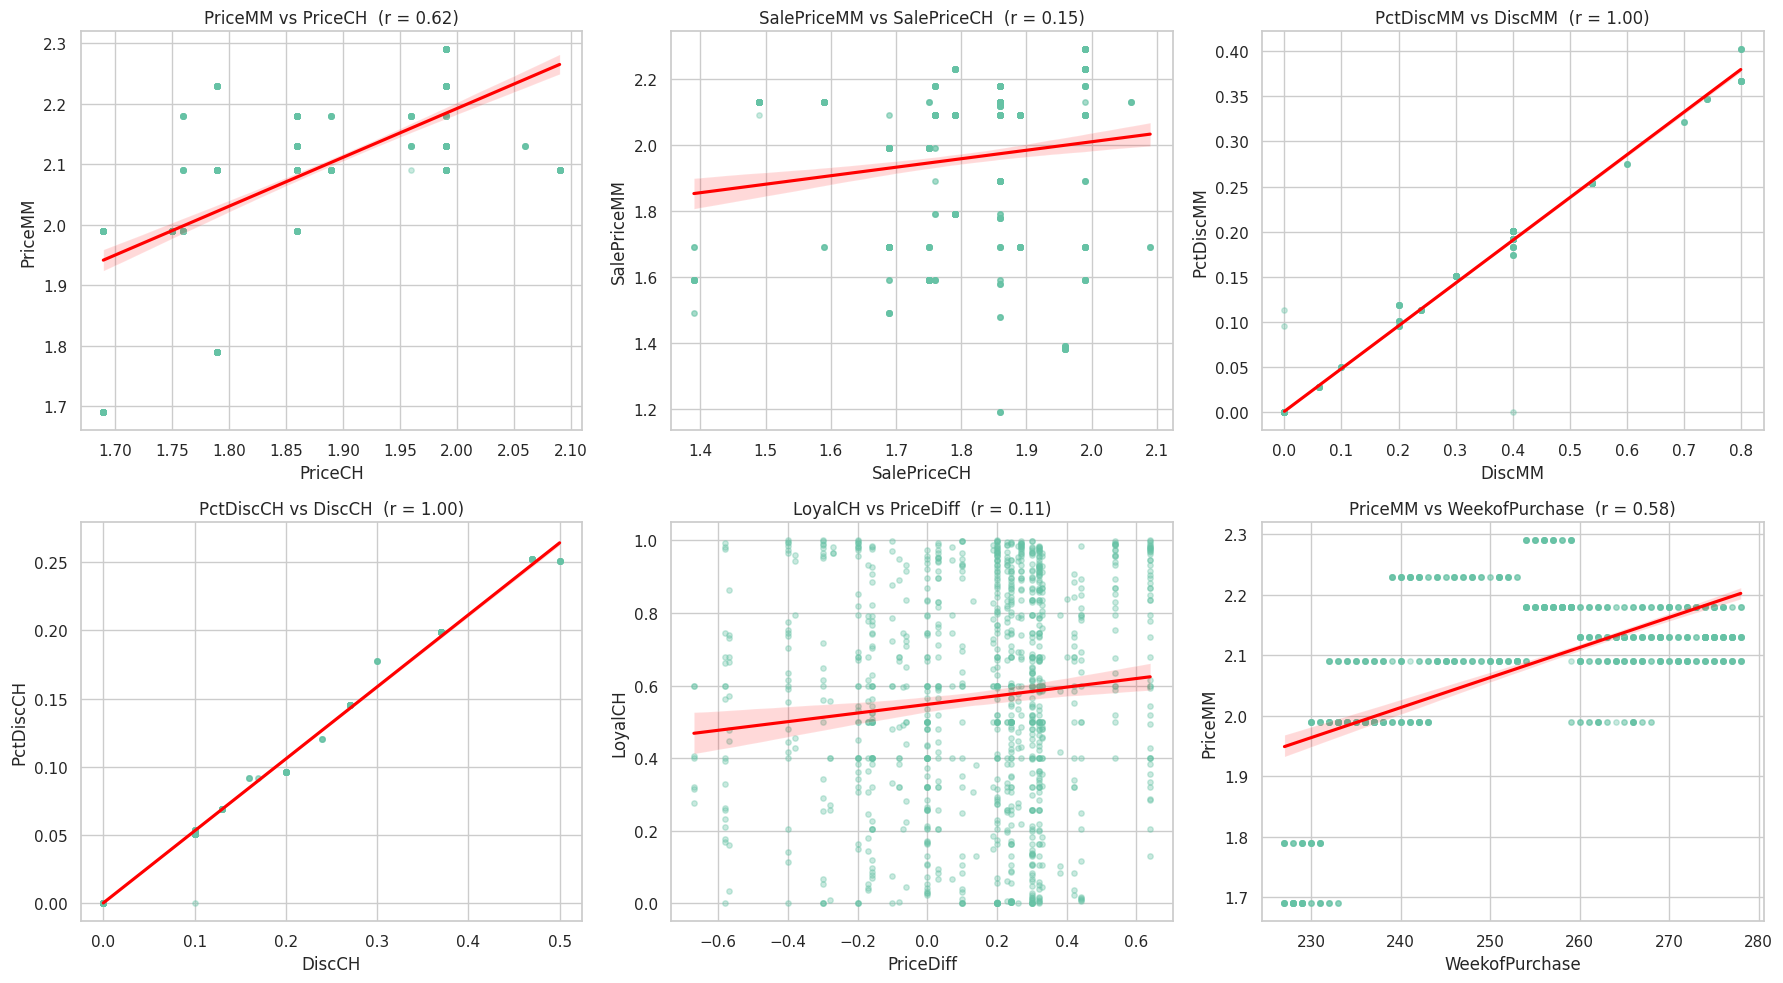

In [24]:
scatter_pairs = [("PriceCH", "PriceMM"), ("SalePriceCH", "SalePriceMM"),
                 ("DiscMM", "PctDiscMM"), ("DiscCH", "PctDiscCH"),
                 ("PriceDiff", "LoyalCH"), ("WeekofPurchase", "PriceMM")]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (x, y) in zip(axes.ravel(), scatter_pairs):
    sns.regplot(x=x, y=y, data=df, ax=ax, scatter_kws={"alpha": 0.35, "s": 15},
                line_kws={"color": "red"})
    r = df[x].corr(df[y])
    ax.set_title(f"{y} vs {x}  (r = {r:.2f})")
plt.tight_layout(); plt.show()

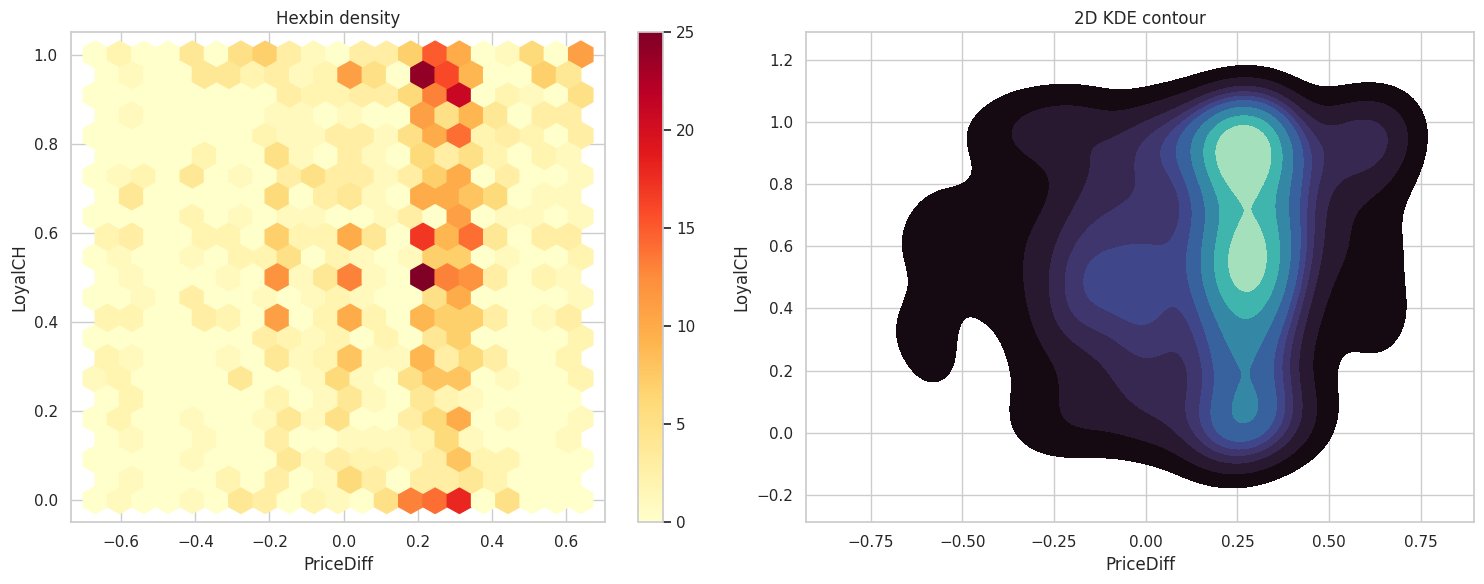

In [25]:
# Hexbin / 2D density — LoyalCH vs PriceDiff
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
hb = axes[0].hexbin(df["PriceDiff"], df["LoyalCH"], gridsize=20, cmap="YlOrRd")
fig.colorbar(hb, ax=axes[0]); axes[0].set_xlabel("PriceDiff"); axes[0].set_ylabel("LoyalCH")
axes[0].set_title("Hexbin density")
sns.kdeplot(x="PriceDiff", y="LoyalCH", data=df, fill=True, cmap="mako", ax=axes[1])
axes[1].set_title("2D KDE contour")
plt.tight_layout(); plt.show()

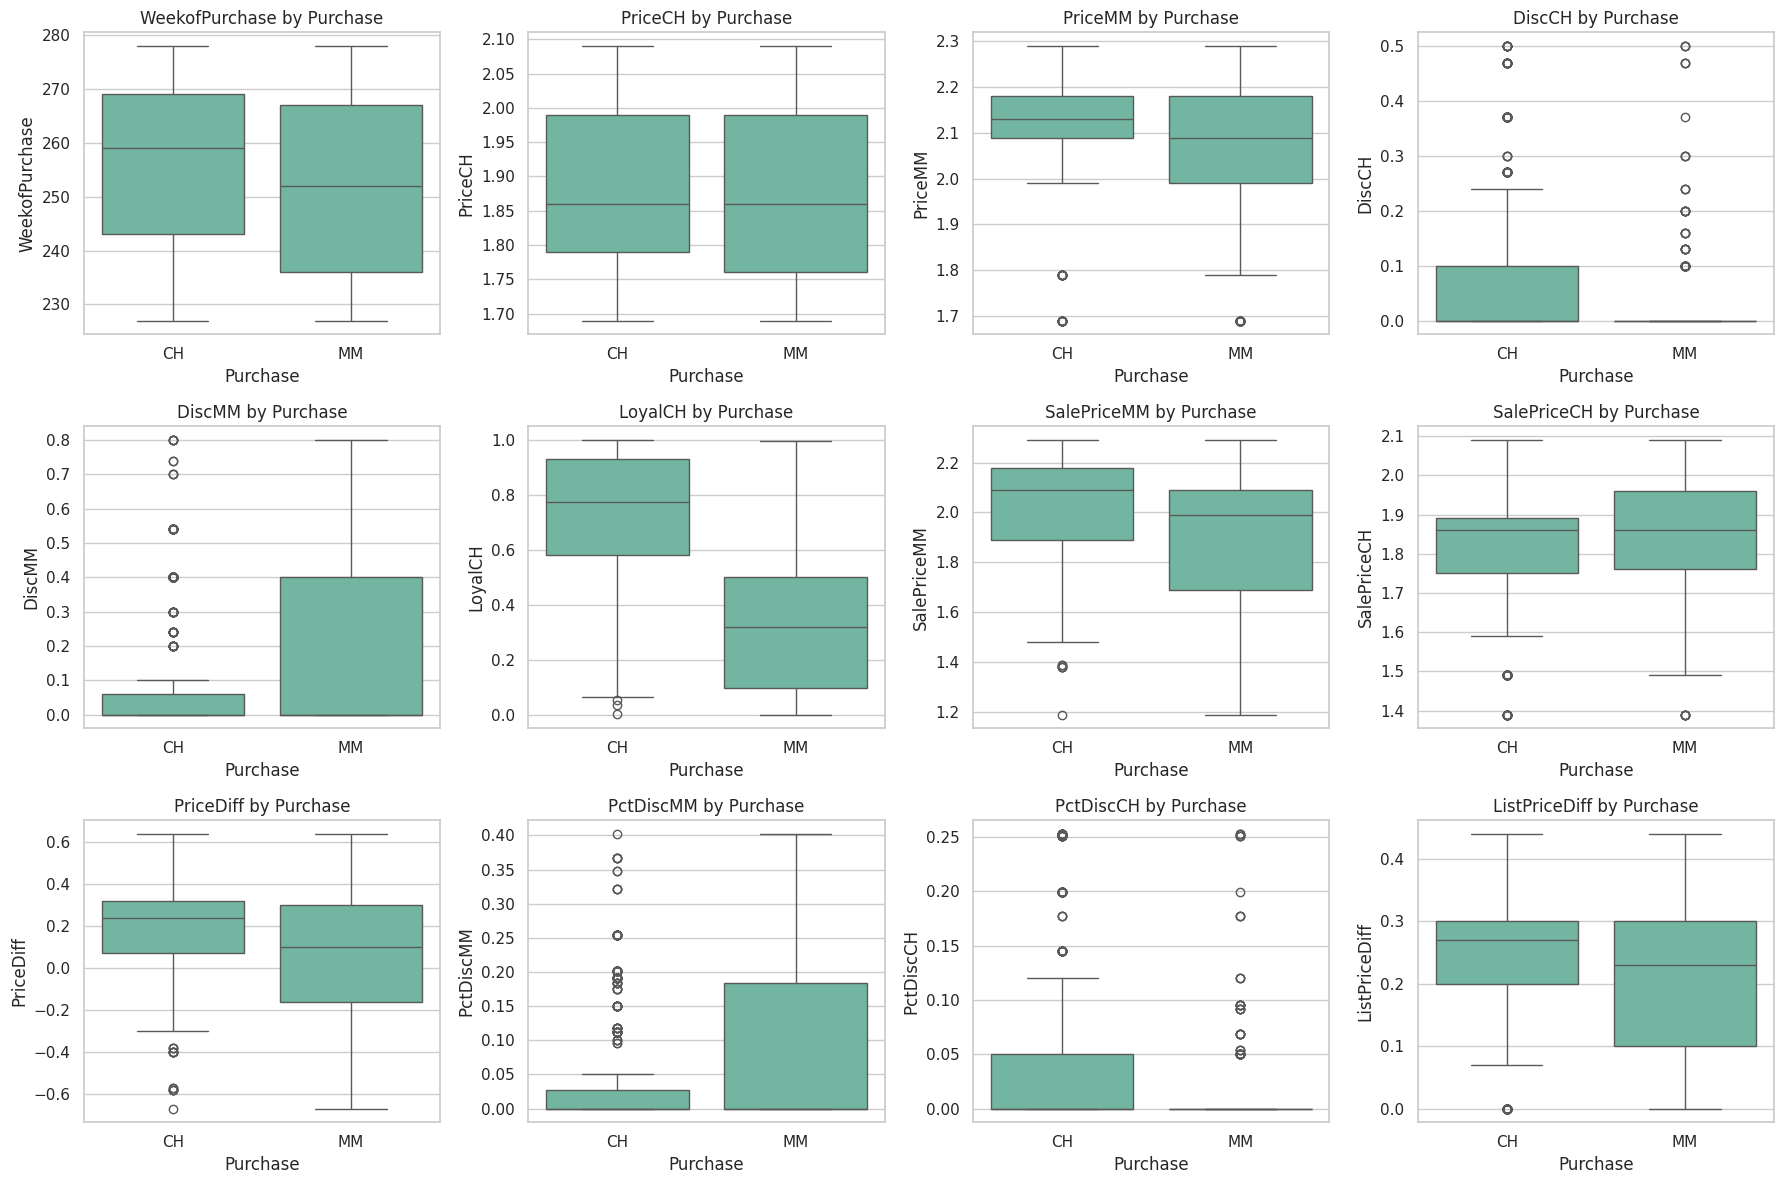

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, c in zip(axes.ravel(), continuous):
    sns.boxplot(x="Purchase", y=c, data=df, ax=ax)
    ax.set_title(f"{c} by Purchase")
plt.tight_layout(); plt.show()

In [27]:
# Group statistics
df.groupby("Purchase")[continuous].agg(["mean", "median", "std"]).T

Purchase                    CH       MM
WeekofPurchase mean   255.9418 251.9376
               median 259.0000 252.0000
               std     14.7705  16.4402
PriceCH        mean     1.8693   1.8645
               median   1.8600   1.8600
               std      0.0967   0.1098
PriceMM        mean     2.1011   2.0599
               median   2.1300   2.0900
               std      0.1149   0.1566
DiscCH         mean     0.0689   0.0252
               median   0.0000   0.0000
               std      0.1345   0.0771
DiscMM         mean     0.0945   0.1675
               median   0.0000   0.0000
               std      0.1820   0.2497
LoyalCH        mean     0.7226   0.3192
               median   0.7757   0.3200
               std      0.2306   0.2447
SalePriceMM    mean     2.0065   1.8937
               median   2.0900   1.9900
               std      0.2258   0.2749
SalePriceCH    mean     1.8004   1.8393
               median   1.8600   1.8600
               std      0.1539   0.1216
PriceDiff      mean     0.2061   0.0529
               median   0.2400   0.1000
               std      0.2455   0.2839
PctDiscMM      mean     0.0458   0.0800
               median   0.0000   0.0000
               std      0.0871   0.1182
PctDiscCH      mean     0.0363   0.0131
               median   0.0000   0.0000
               std      0.0714   0.0404
ListPriceDiff  mean     0.2321   0.1959
               median   0.2700   0.2300
               std      0.1005   0.1143

In [28]:
# Two-sample tests: CH vs MM
rows = []
ch, mm = df[df.Purchase == "CH"], df[df.Purchase == "MM"]
for c in continuous:
    t, p_t = stats.ttest_ind(ch[c], mm[c], equal_var=False)       # Welch t-test
    u, p_u = stats.mannwhitneyu(ch[c], mm[c], alternative="two-sided")
    pooled = np.sqrt((ch[c].var() + mm[c].var()) / 2)
    d = (ch[c].mean() - mm[c].mean()) / pooled if pooled > 0 else np.nan
    rows.append({"variable": c, "mean_CH": ch[c].mean(), "mean_MM": mm[c].mean(),
                 "Welch_t": t, "p_t": p_t, "MannWhitney_U": u, "p_U": p_u,
                 "Cohen_d": d, "Significant @5%": "Yes" if p_t < 0.05 else "No"})
pd.DataFrame(rows).set_index("variable").sort_values("p_t")

,mean_CH,mean_MM,Welch_t,p_t,MannWhitney_U,p_U,Cohen_d,Significant @5%
variable,,,,,,,,
LoyalCH,0.7226,0.3192,26.8936,0.0000,"237,962.0000",0.0000,1.6969,Yes
PriceDiff,0.2061,0.0529,9.0703,0.0000,"178,870.5000",0.0000,0.5776,Yes
SalePriceMM,2.0065,1.8937,7.0078,0.0000,"168,982.5000",0.0000,0.4486,Yes
PctDiscCH,0.0363,0.0131,6.7635,0.0000,"154,716.0000",0.0000,0.3992,Yes
DiscCH,0.0689,0.0252,6.7375,0.0000,"154,775.5000",0.0000,0.3981,Yes
ListPriceDiff,0.2321,0.1959,5.3019,0.0000,"163,322.0000",0.0000,0.3370,Yes
DiscMM,0.0945,0.1675,-5.1622,0.0000,"117,140.5000",0.0000,-0.3343,Yes
PctDiscMM,0.0458,0.0800,-5.0975,0.0000,"117,436.0000",0.0000,-0.3298,Yes
PriceMM,2.1011,2.0599,4.6359,0.0000,"155,611.0000",0.0001,0.3001,Yes


,ANOVA_F,p_ANOVA,Kruskal_H,p_Kruskal
variable,,,,
LoyalCH,59.8840,0.0000,186.7001,0.0000
PriceCH,87.2587,0.0000,240.9906,0.0000
PriceMM,15.6474,0.0000,76.1037,0.0000
PriceDiff,10.3857,0.0000,39.0533,0.0000
SalePriceMM,18.1076,0.0000,68.8323,0.0000
SalePriceCH,84.2130,0.0000,308.3835,0.0000


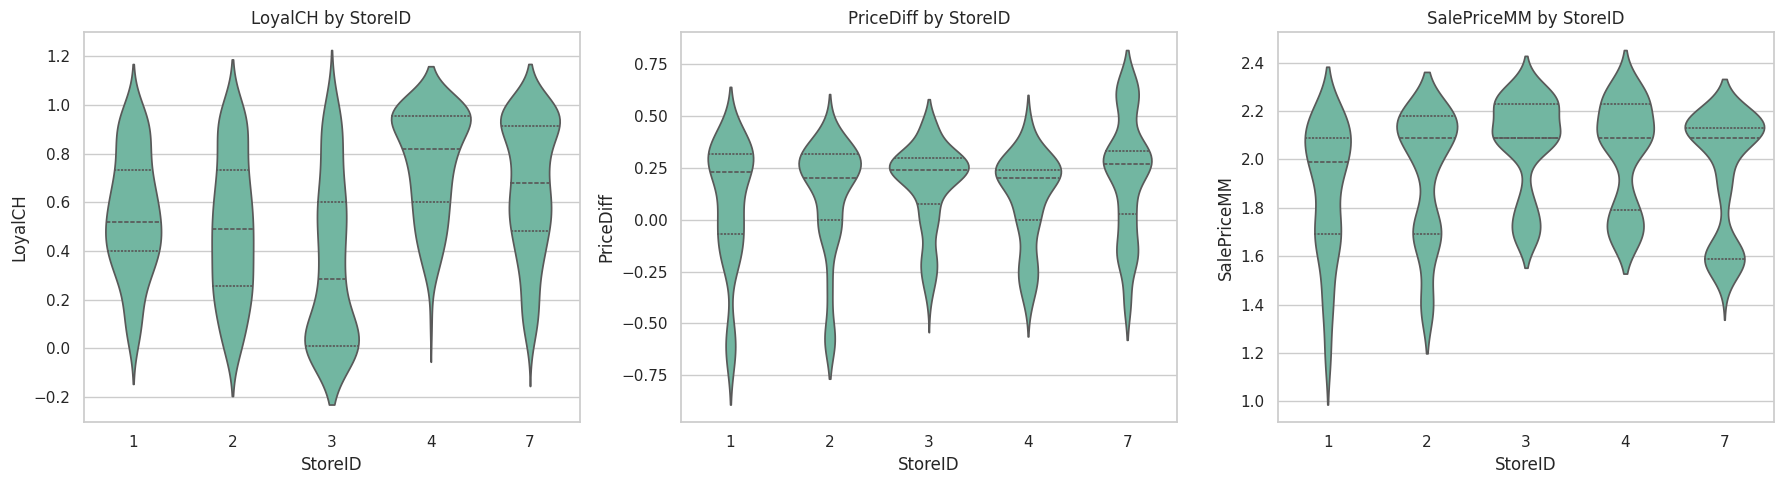

In [29]:
# One-way ANOVA & Kruskal-Wallis across stores
rows = []
for c in ["LoyalCH", "PriceCH", "PriceMM", "PriceDiff", "SalePriceMM", "SalePriceCH"]:
    groups = [g[c].values for _, g in df.groupby("StoreID")]
    f, p_f = stats.f_oneway(*groups)
    h, p_h = stats.kruskal(*groups)
    rows.append({"variable": c, "ANOVA_F": f, "p_ANOVA": p_f, "Kruskal_H": h, "p_Kruskal": p_h})
display(pd.DataFrame(rows).set_index("variable"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, c in zip(axes, ["LoyalCH", "PriceDiff", "SalePriceMM"]):
    sns.violinplot(x="StoreID", y=c, data=df, ax=ax, inner="quartile")
    ax.set_title(f"{c} by StoreID")
plt.tight_layout(); plt.show()

In [30]:
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum(); r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

rows = []
for c in ["StoreID", "Store7", "SpecialCH", "SpecialMM"]:
    ct = pd.crosstab(df[c], df["Purchase"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({"variable": c, "chi2": chi2, "dof": dof, "p_value": p, "Cramers_V": cramers_v(ct)})
    print(f"\n----- {c} x Purchase (row %) -----")
    print((pd.crosstab(df[c], df["Purchase"], normalize="index") * 100).round(1))
pd.DataFrame(rows).set_index("variable")


----- StoreID x Purchase (row %) -----
Purchase      CH      MM
StoreID                 
1        54.1000 45.9000
2        48.2000 51.8000
3        38.3000 61.7000
4        80.6000 19.4000
7        77.0000 23.0000

----- Store7 x Purchase (row %) -----
Purchase      CH      MM
Store7                  
No       53.1000 46.9000
Yes      77.0000 23.0000

----- SpecialCH x Purchase (row %) -----
Purchase       CH      MM
SpecialCH                
0         58.4000 41.6000
1         76.4000 23.6000

----- SpecialMM x Purchase (row %) -----
Purchase       CH      MM
SpecialMM                
0         64.8000 35.2000
1         41.6000 58.4000


,chi2,dof,p_value,Cramers_V
variable,,,,
StoreID,121.5503,4,0.0000,0.3370
Store7,55.9819,1,0.0000,0.2287
SpecialCH,17.6082,1,0.0000,0.1283
SpecialMM,31.7216,1,0.0000,0.1722


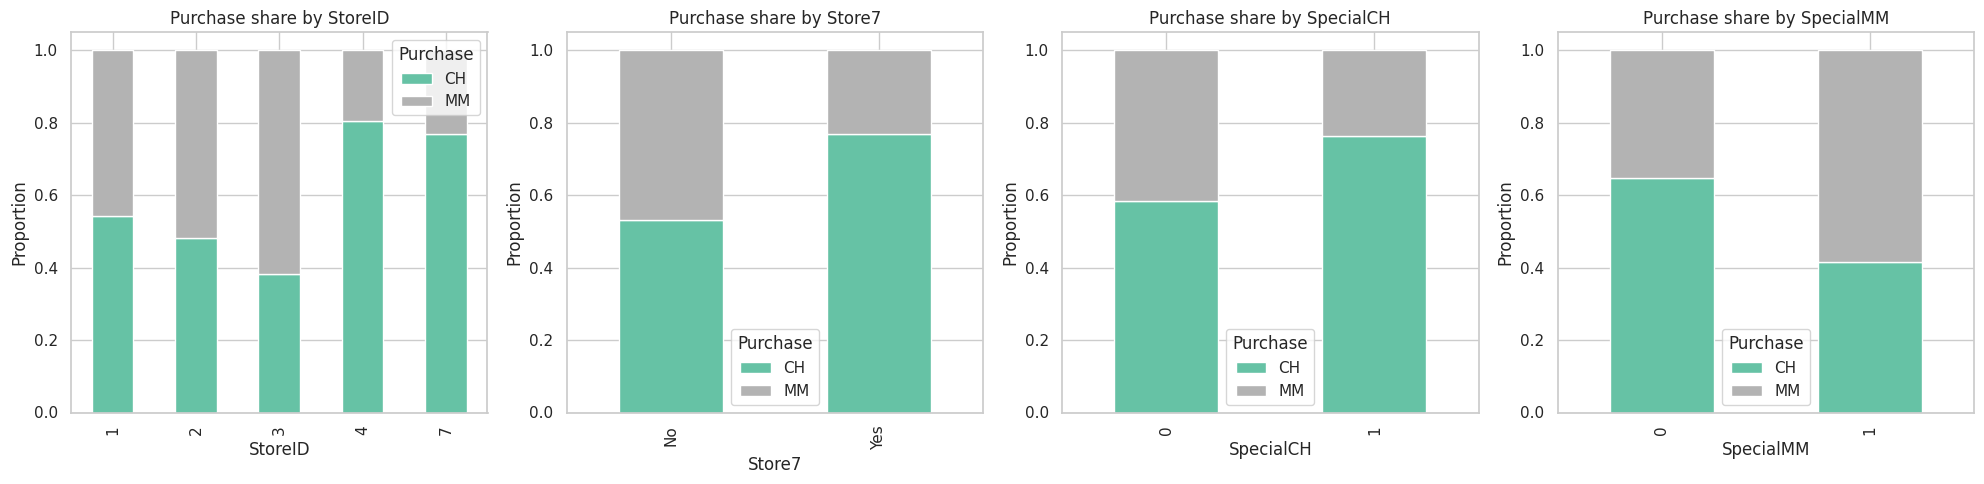

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, c in zip(axes, ["StoreID", "Store7", "SpecialCH", "SpecialMM"]):
    pd.crosstab(df[c], df["Purchase"], normalize="index").plot(kind="bar", stacked=True, ax=ax,
                                                              colormap="Set2")
    ax.set_title(f"Purchase share by {c}"); ax.set_ylabel("Proportion"); ax.legend(title="Purchase")
plt.tight_layout(); plt.show()

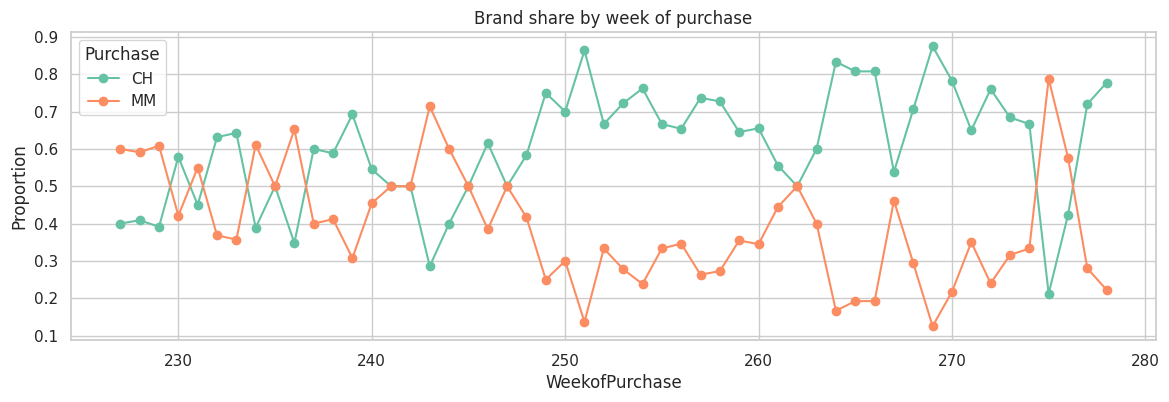

In [32]:
# Purchase share over time (week)
wk = pd.crosstab(df["WeekofPurchase"], df["Purchase"], normalize="index")
wk.plot(figsize=(14, 4), marker="o")
plt.title("Brand share by week of purchase"); plt.ylabel("Proportion"); plt.show()

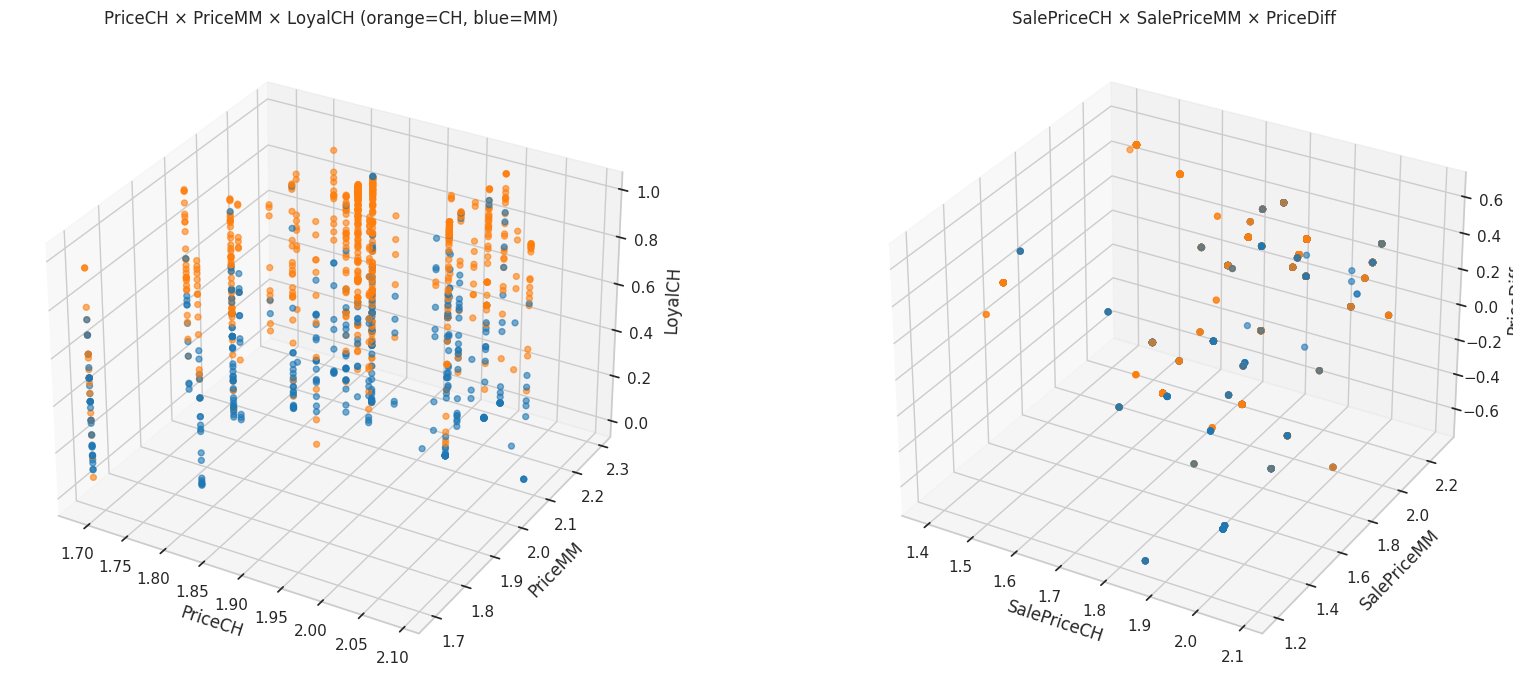

In [33]:
colors = df["Purchase"].map({"CH": "tab:orange", "MM": "tab:blue"})
fig = plt.figure(figsize=(18, 7))

ax = fig.add_subplot(121, projection="3d")
ax.scatter(df["PriceCH"], df["PriceMM"], df["LoyalCH"], c=colors, s=18, alpha=0.6)
ax.set_xlabel("PriceCH"); ax.set_ylabel("PriceMM"); ax.set_zlabel("LoyalCH")
ax.set_title("PriceCH × PriceMM × LoyalCH (orange=CH, blue=MM)")

ax = fig.add_subplot(122, projection="3d")
ax.scatter(df["SalePriceCH"], df["SalePriceMM"], df["PriceDiff"], c=colors, s=18, alpha=0.6)
ax.set_xlabel("SalePriceCH"); ax.set_ylabel("SalePriceMM"); ax.set_zlabel("PriceDiff")
ax.set_title("SalePriceCH × SalePriceMM × PriceDiff")
plt.tight_layout(); plt.show()

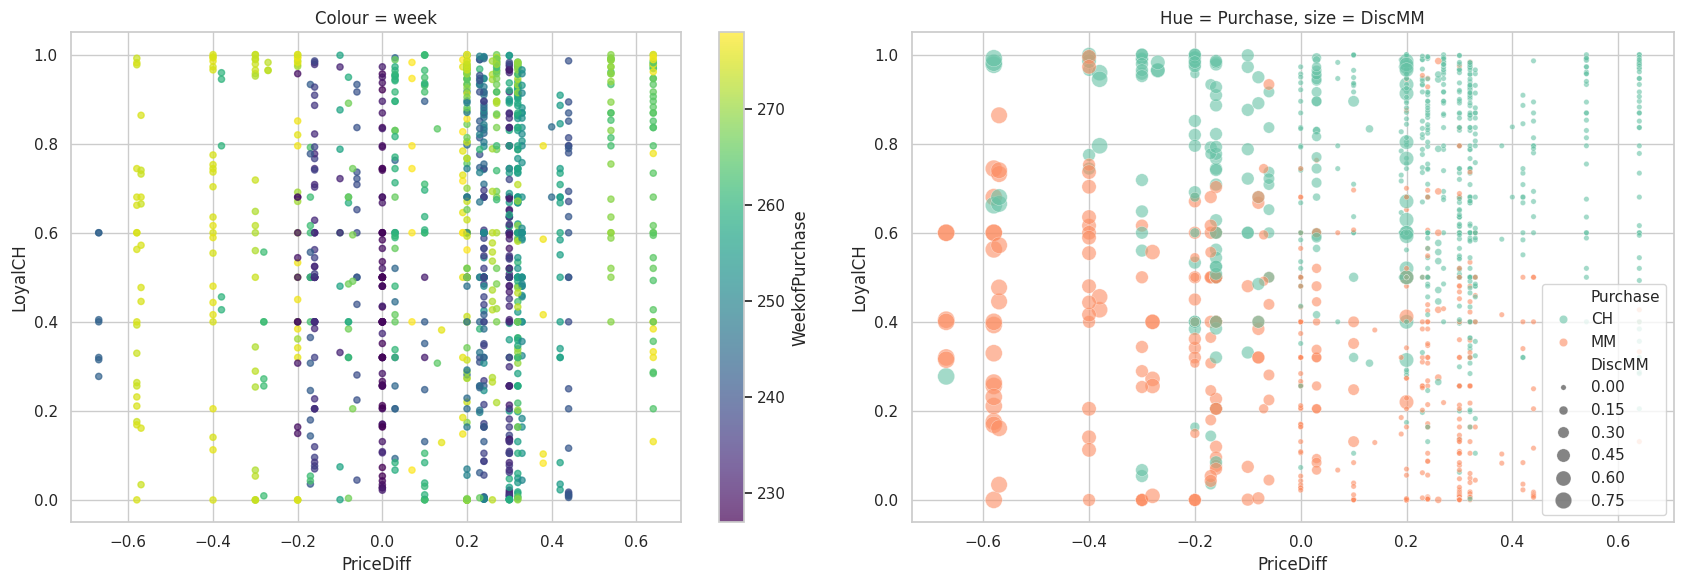

In [34]:
# Third variable encoded as colour / size in a 2D plane
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sc = axes[0].scatter(df["PriceDiff"], df["LoyalCH"], c=df["WeekofPurchase"], cmap="viridis",
                     s=20, alpha=0.7)
fig.colorbar(sc, ax=axes[0], label="WeekofPurchase")
axes[0].set_xlabel("PriceDiff"); axes[0].set_ylabel("LoyalCH"); axes[0].set_title("Colour = week")
sns.scatterplot(x="PriceDiff", y="LoyalCH", hue="Purchase", size="DiscMM", sizes=(15, 150),
                data=df, alpha=0.6, ax=axes[1])
axes[1].set_title("Hue = Purchase, size = DiscMM")
plt.tight_layout(); plt.show()

In [35]:
# Optional interactive 3D (requires plotly: pip install plotly)
try:
    import plotly.express as px
    fig = px.scatter_3d(df, x="PriceDiff", y="LoyalCH", z="WeekofPurchase",
                        color="Purchase", symbol="Store7", opacity=0.7,
                        title="Interactive 3D: PriceDiff × LoyalCH × Week")
    fig.update_traces(marker=dict(size=3)); fig.show()
except ImportError:
    print("plotly not installed — skipping interactive plot.")

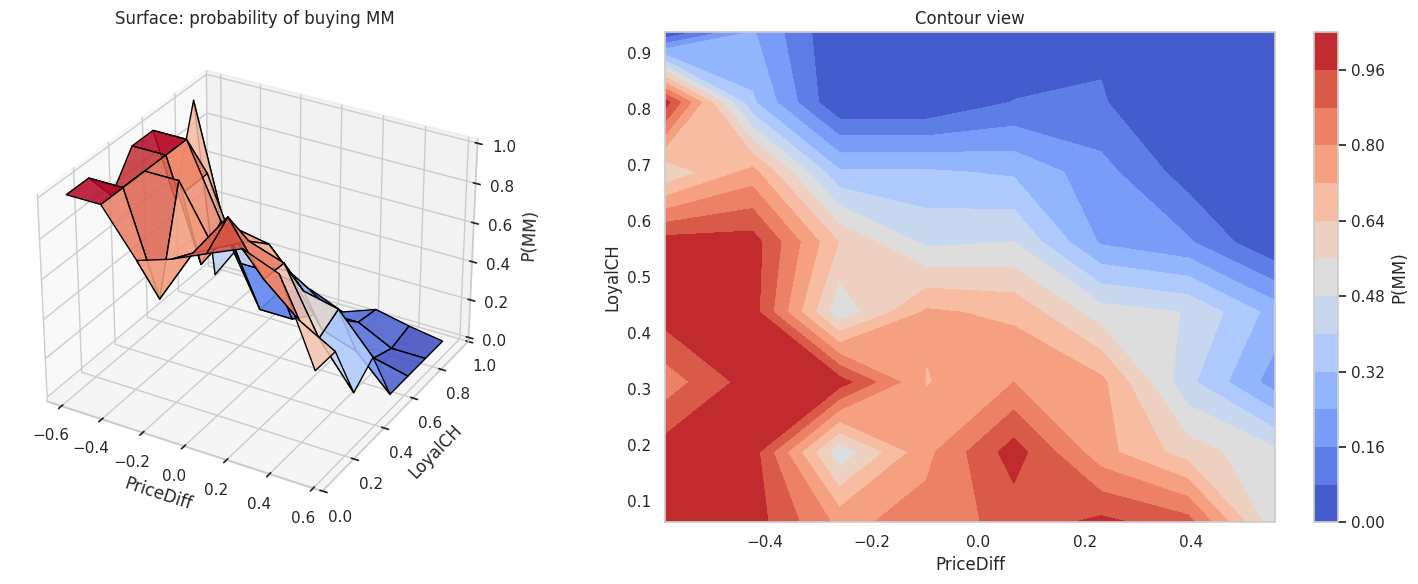

In [36]:
x_bins = pd.cut(df["PriceDiff"], bins=8)
y_bins = pd.cut(df["LoyalCH"], bins=8)
surf = df.pivot_table(index=y_bins, columns=x_bins, values="Purchase_bin", aggfunc="mean", observed=False)
surf = surf.interpolate(axis=0, limit_direction="both").interpolate(axis=1, limit_direction="both")

X, Y = np.meshgrid([b.mid for b in surf.columns], [b.mid for b in surf.index])
fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(X, Y, surf.values, cmap="coolwarm", edgecolor="k", alpha=0.85)
ax.set_xlabel("PriceDiff"); ax.set_ylabel("LoyalCH"); ax.set_zlabel("P(MM)")
ax.set_title("Surface: probability of buying MM")
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X, Y, surf.values, levels=12, cmap="coolwarm")
fig.colorbar(cs, ax=ax2, label="P(MM)")
ax2.set_xlabel("PriceDiff"); ax2.set_ylabel("LoyalCH"); ax2.set_title("Contour view")
plt.tight_layout(); plt.show()

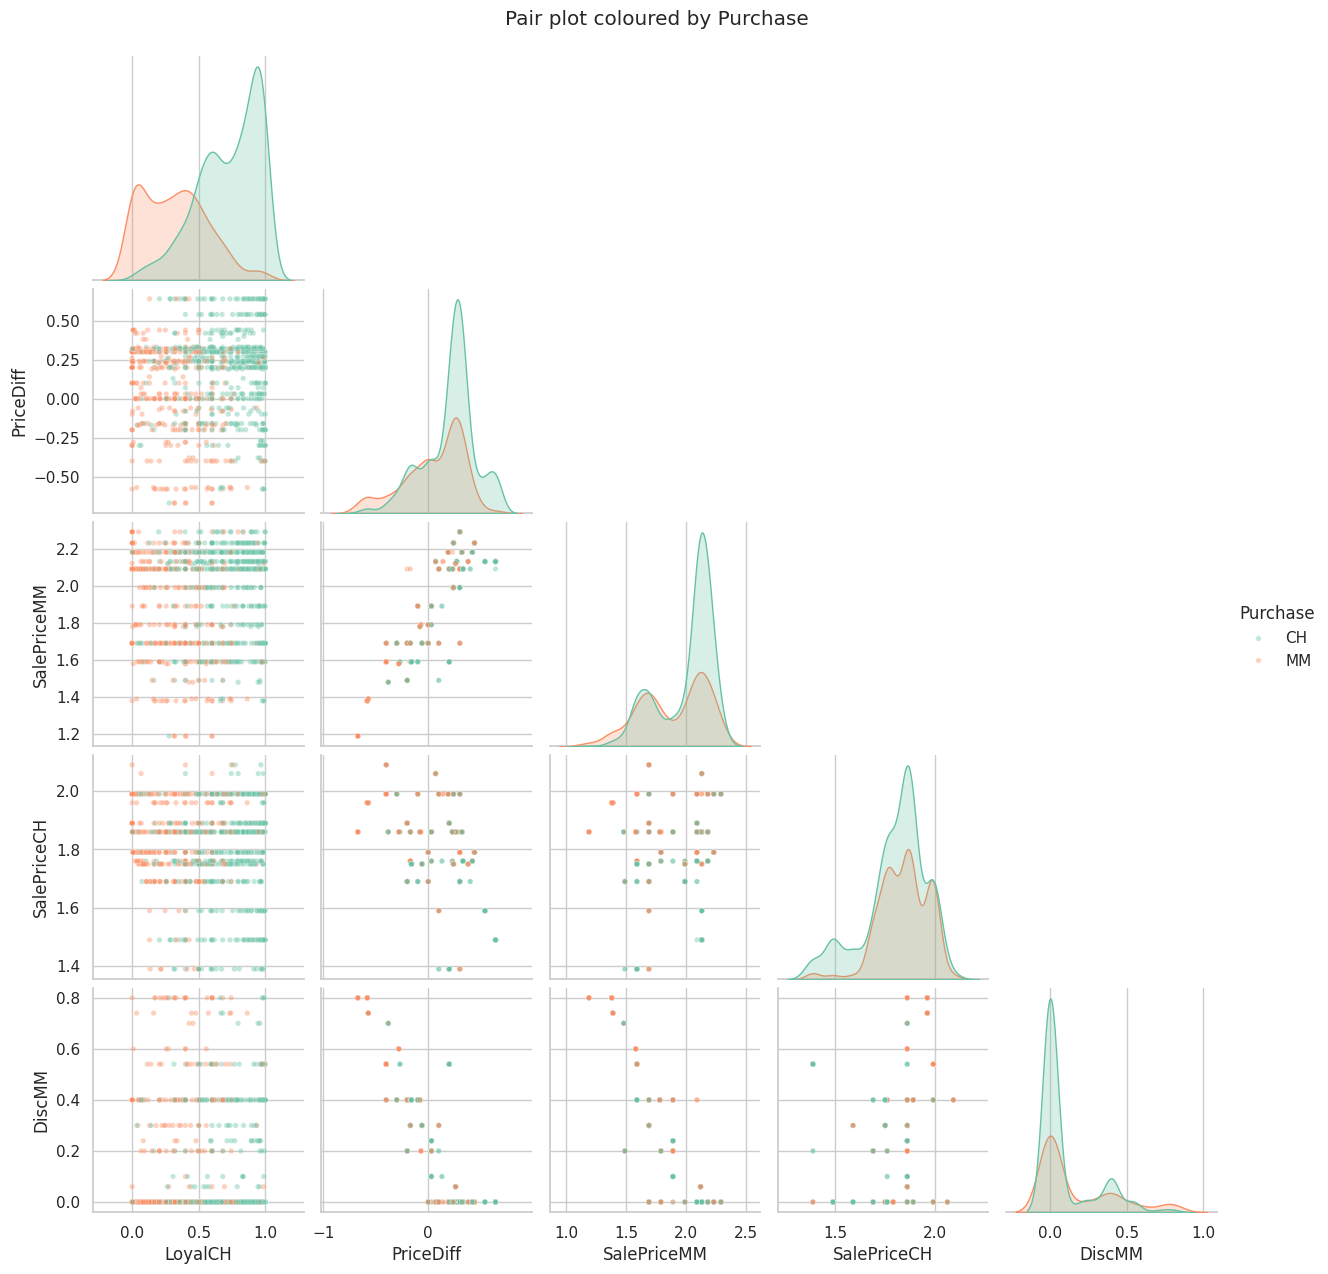

In [37]:
sns.pairplot(df[["LoyalCH", "PriceDiff", "SalePriceMM", "SalePriceCH", "DiscMM", "Purchase"]],
             hue="Purchase", corner=True, plot_kws={"alpha": 0.4, "s": 15}, diag_kind="kde")
plt.suptitle("Pair plot coloured by Purchase", y=1.02); plt.show()

SpecialMM,No MM special,MM special
StoreID,,
1,31.5000,77.6000
2,47.4000,61.8000
3,61.6000,66.7000
4,18.3000,37.5000
7,21.7000,33.3000


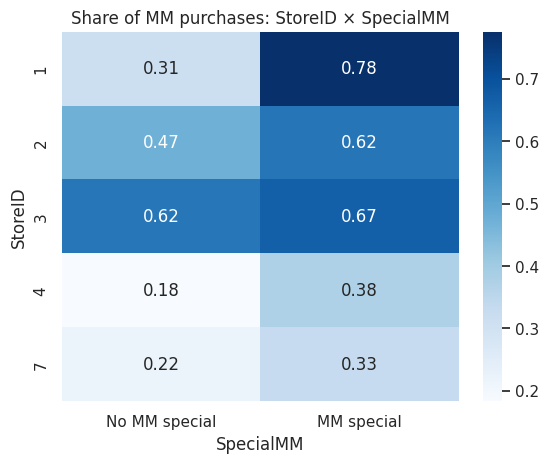

In [38]:
# Three-way table: StoreID × SpecialMM × Purchase (MM share)
pt = pd.pivot_table(df, values="Purchase_bin", index="StoreID", columns="SpecialMM",
                    aggfunc="mean").rename(columns={0: "No MM special", 1: "MM special"})
display((pt * 100).round(1))
sns.heatmap(pt, annot=True, fmt=".2f", cmap="Blues")
plt.title("Share of MM purchases: StoreID × SpecialMM"); plt.show()

In [39]:
# Grouped multi-variable summary: Store × Purchase
df.groupby(["StoreID", "Purchase"])[["LoyalCH", "PriceDiff", "SalePriceMM", "SalePriceCH"]].mean().unstack()

LoyalCH        PriceDiff         SalePriceMM        SalePriceCH  \
Purchase      CH     MM        CH      MM          CH     MM          CH   
StoreID                                                                    
1         0.6670 0.4070    0.1995 -0.0783      1.9800 1.7301      1.7805   
2         0.6782 0.3242    0.1807  0.0426      2.0156 1.8494      1.8349   
3         0.6552 0.1638    0.1856  0.1483      2.0929 2.0462      1.9073   
4         0.8086 0.5729    0.0996  0.1148      2.0218 2.0233      1.9221   
7         0.7405 0.3808    0.2673  0.0212      1.9813 1.8316      1.7142   

                 
Purchase     MM  
StoreID          
1        1.8015  
2        1.8060  
3        1.8974  
4        1.9085  
7        1.8104

In [40]:
def partial_corr(data, x, y, z):
    # correlation of x and y after removing the linear effect of z
    rx = data[x] - np.polyval(np.polyfit(data[z], data[x], 1), data[z])
    ry = data[y] - np.polyval(np.polyfit(data[z], data[y], 1), data[z])
    return stats.pearsonr(rx, ry)

for x, y, z in [("PriceDiff", "Purchase_bin", "LoyalCH"),
                ("LoyalCH", "Purchase_bin", "PriceDiff"),
                ("SalePriceMM", "Purchase_bin", "DiscMM")]:
    r0 = df[x].corr(df[y]); r, p = partial_corr(df, x, y, z)
    print(f"r({x}, {y}) = {r0:+.3f}   |   partial r controlling {z} = {r:+.3f} (p={p:.4f})")

r(PriceDiff, Purchase_bin) = -0.275   |   partial r controlling LoyalCH = -0.273 (p=0.0000)
r(LoyalCH, Purchase_bin) = -0.640   |   partial r controlling PriceDiff = -0.640 (p=0.0000)
r(SalePriceMM, Purchase_bin) = -0.218   |   partial r controlling DiscMM = -0.147 (p=0.0000)


,explained_var,cumulative
PC1,0.3260,0.3260
PC2,0.2328,0.5588
PC3,0.2298,0.7886
PC4,0.1095,0.8981
PC5,0.0790,0.9771
PC6,0.0218,0.9989
PC7,0.0005,0.9994
PC8,0.0003,0.9997
PC9,0.0001,0.9998
PC10,0.0001,1.0000


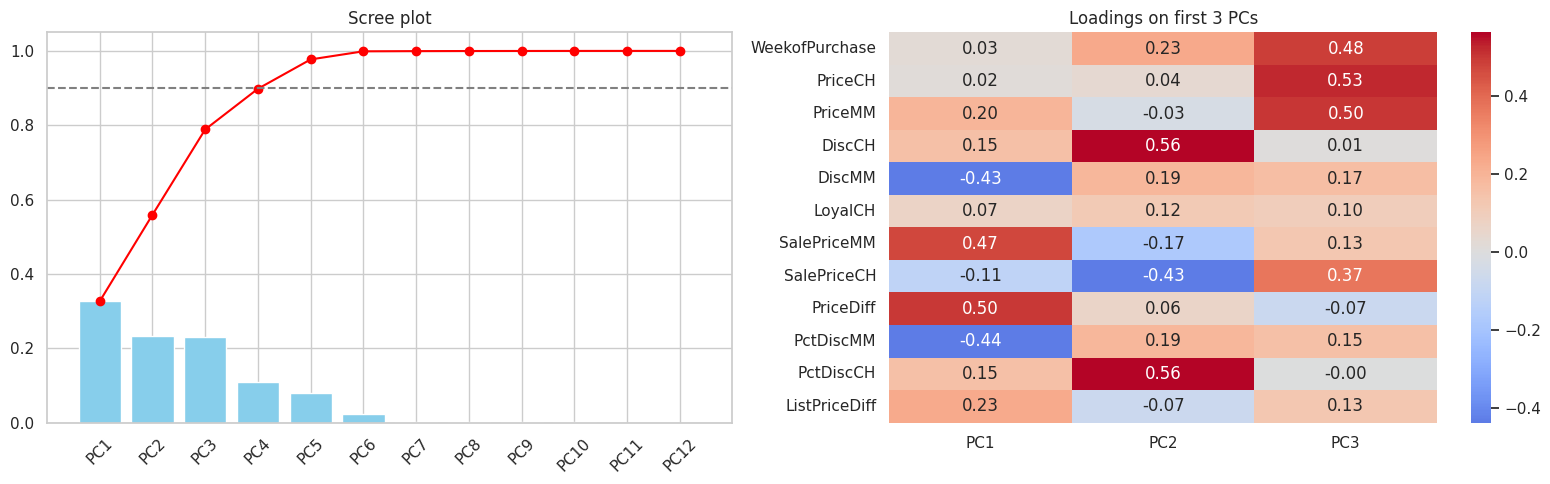

In [41]:
pca_full = PCA().fit(StandardScaler().fit_transform(df[continuous]))
ev = pd.DataFrame({"explained_var": pca_full.explained_variance_ratio_,
                   "cumulative": np.cumsum(pca_full.explained_variance_ratio_)},
                  index=[f"PC{i+1}" for i in range(len(continuous))])
display(ev)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(ev.index, ev.explained_var, color="skyblue")
axes[0].plot(ev.index, ev.cumulative, "ro-"); axes[0].axhline(0.9, ls="--", color="gray")
axes[0].set_title("Scree plot"); axes[0].tick_params(axis="x", rotation=45)
loadings = pd.DataFrame(pca_full.components_[:3].T, index=continuous, columns=["PC1", "PC2", "PC3"])
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Loadings on first 3 PCs")
plt.tight_layout(); plt.show()

## 6. Clustering Preparation


In [42]:
cluster_features = ["PriceCH", "PriceMM", "DiscCH", "DiscMM", "SpecialCH", "SpecialMM",
                    "LoyalCH", "WeekofPurchase", "Store7_bin"]
X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Clustering matrix:", X_scaled.shape)

# PCA projections used only for visualising clusters
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
pca3 = PCA(n_components=3, random_state=RANDOM_STATE).fit(X_scaled)
X_pca2, X_pca3 = pca2.transform(X_scaled), pca3.transform(X_scaled)
print("Variance captured — 2 PCs: {:.1%}, 3 PCs: {:.1%}".format(
      pca2.explained_variance_ratio_.sum(), pca3.explained_variance_ratio_.sum()))

Clustering matrix: (1070, 9)
Variance captured — 2 PCs: 48.8%, 3 PCs: 65.4%


## 7. K-Means Clustering

In [43]:
k_range = range(2, 11)
km_metrics = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)
    km_metrics.append({"k": k, "inertia(WCSS)": km.inertia_,
                       "silhouette": silhouette_score(X_scaled, km.labels_),
                       "davies_bouldin": davies_bouldin_score(X_scaled, km.labels_),
                       "calinski_harabasz": calinski_harabasz_score(X_scaled, km.labels_)})
km_metrics = pd.DataFrame(km_metrics).set_index("k")
km_metrics

,inertia(WCSS),silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,"7,694.5419",0.2153,1.7291,268.6410
3,"6,216.7213",0.2678,1.4579,292.9205
4,"5,140.8916",0.3014,1.2769,310.2827
5,"4,567.5756",0.2586,1.2288,295.0954
6,"4,176.6906",0.2524,1.2939,277.8430
7,"3,803.7583",0.2761,1.3446,271.3673
8,"3,466.4906",0.2898,1.2293,269.7519
9,"3,216.6957",0.3038,1.2012,264.4218
10,"3,012.9565",0.3081,1.1244,258.6631


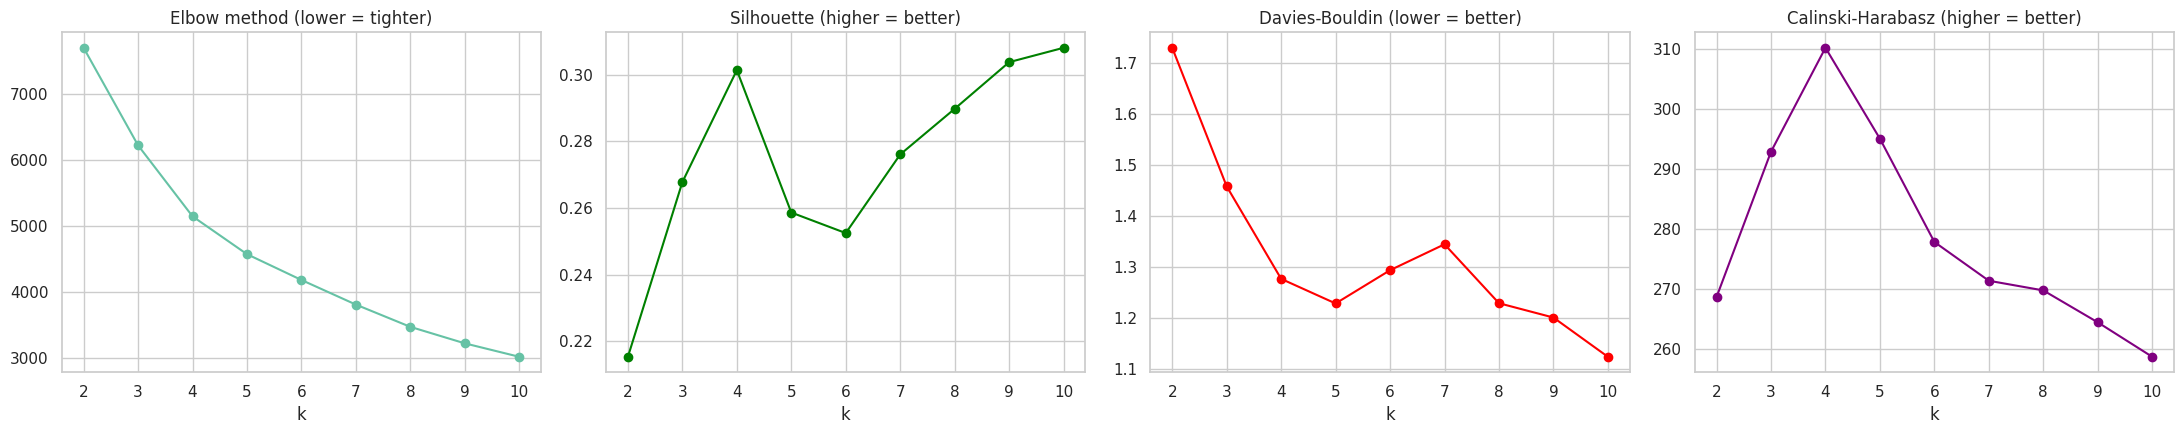

k with best silhouette: 10


In [44]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
km_metrics["inertia(WCSS)"].plot(marker="o", ax=axes[0], title="Elbow method (lower = tighter)")
km_metrics["silhouette"].plot(marker="o", color="green", ax=axes[1], title="Silhouette (higher = better)")
km_metrics["davies_bouldin"].plot(marker="o", color="red", ax=axes[2], title="Davies-Bouldin (lower = better)")
km_metrics["calinski_harabasz"].plot(marker="o", color="purple", ax=axes[3], title="Calinski-Harabasz (higher = better)")
for a in axes: a.set_xlabel("k")
plt.tight_layout(); plt.show()

best_k = int(km_metrics["silhouette"].idxmax())
print("k with best silhouette:", best_k)

In [45]:
kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=RANDOM_STATE).fit(X_scaled)
df["KMeans_Cluster"] = kmeans.labels_

print("Cluster sizes:"); print(df["KMeans_Cluster"].value_counts().sort_index())
print(f"\nSilhouette: {silhouette_score(X_scaled, kmeans.labels_):.3f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, kmeans.labels_):.3f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(X_scaled, kmeans.labels_):.1f}")

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=cluster_features)
centroids.index.name = "KMeans_Cluster"
print("\nCluster centroids (original units):")
centroids

Cluster sizes:
KMeans_Cluster
0    167
1    151
2     82
3    198
4     70
5     91
6     75
7    118
8     56
9     62
Name: count, dtype: int64

Silhouette: 0.311
Davies-Bouldin: 1.150
Calinski-Harabasz: 265.3

Cluster centroids (original units):


,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,WeekofPurchase,Store7_bin
KMeans_Cluster,,,,,,,,,
0,1.8663,2.1359,0.0203,0.0449,0.0539,-0.0000,0.6842,258.1677,1.0000
1,1.7752,2.0838,0.0011,0.0079,-0.0000,-0.0000,0.4816,241.4636,0.0000
2,1.7241,1.7461,0.0220,0.0122,0.1951,-0.0000,0.4557,229.5488,0.0732
3,1.9466,2.1630,0.0320,0.0056,0.0202,0.0253,0.7794,260.1414,0.0000
4,1.9311,2.1571,0.0000,0.6323,-0.0000,1.0000,0.4892,266.8000,0.1286
5,1.8771,2.1300,0.3860,0.1246,0.8681,0.1319,0.7222,269.6374,1.0000
6,1.7737,1.9532,0.0107,0.1960,-0.0000,1.0000,0.4913,243.1333,0.2267
7,1.9529,2.1624,0.0319,0.0246,0.0085,0.0593,0.1466,261.0424,0.0085
8,1.7393,1.9900,0.0000,0.3571,0.5000,0.0714,0.5394,234.1786,1.0000


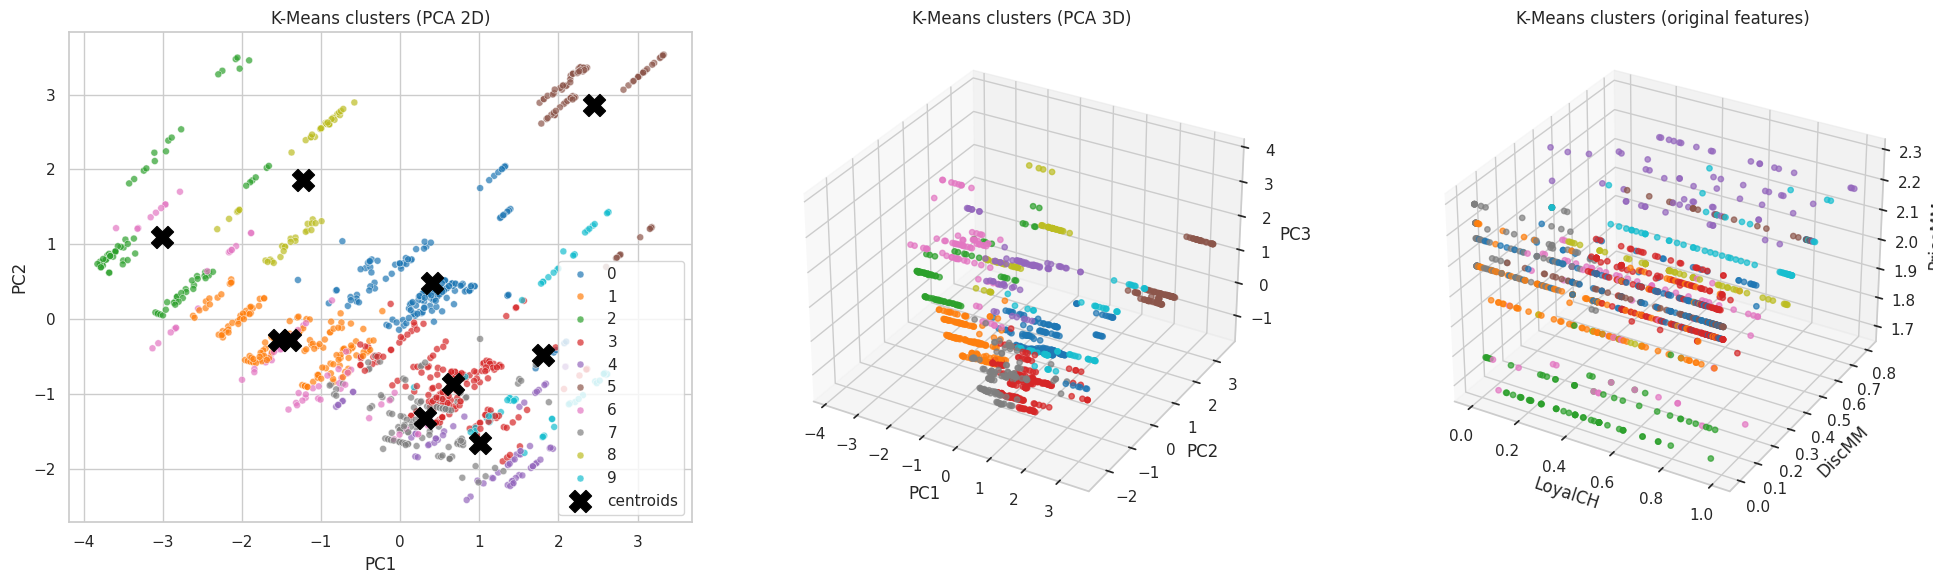

In [46]:
fig = plt.figure(figsize=(20, 6))
ax1 = fig.add_subplot(131)
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=df["KMeans_Cluster"], palette="tab10",
                s=25, alpha=0.7, ax=ax1)
c2 = pca2.transform(kmeans.cluster_centers_)
ax1.scatter(c2[:, 0], c2[:, 1], c="black", marker="X", s=250, label="centroids")
ax1.set_title("K-Means clusters (PCA 2D)"); ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2"); ax1.legend()

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=df["KMeans_Cluster"], cmap="tab10", s=15, alpha=0.7)
ax2.set_title("K-Means clusters (PCA 3D)"); ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(df["LoyalCH"], df["DiscMM"], df["PriceMM"], c=df["KMeans_Cluster"], cmap="tab10", s=15, alpha=0.7)
ax3.set_xlabel("LoyalCH"); ax3.set_ylabel("DiscMM"); ax3.set_zlabel("PriceMM")
ax3.set_title("K-Means clusters (original features)")
plt.tight_layout(); plt.show()

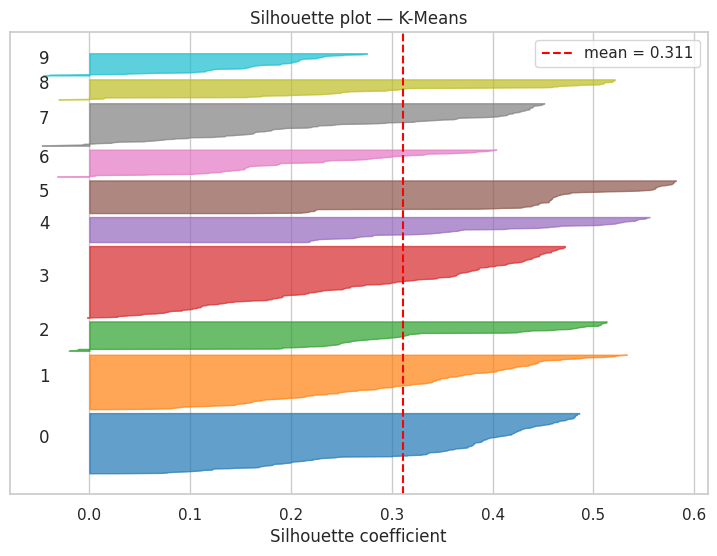

In [47]:
# Silhouette plot per sample
sil = silhouette_samples(X_scaled, kmeans.labels_)
fig, ax = plt.subplots(figsize=(9, 6)); y_lo = 10
for i in range(best_k):
    v = np.sort(sil[kmeans.labels_ == i]); y_hi = y_lo + len(v)
    ax.fill_betweenx(np.arange(y_lo, y_hi), 0, v, alpha=0.7, color=plt.cm.tab10(i))
    ax.text(-0.05, y_lo + len(v) / 2, str(i)); y_lo = y_hi + 10
ax.axvline(sil.mean(), color="red", ls="--", label=f"mean = {sil.mean():.3f}")
ax.set_title("Silhouette plot — K-Means"); ax.set_xlabel("Silhouette coefficient"); ax.set_yticks([]); ax.legend()
plt.show()

In [48]:
profile_cols = cluster_features + ["SalePriceCH", "SalePriceMM", "PriceDiff"]
km_profile = df.groupby("KMeans_Cluster")[profile_cols].mean()
km_profile["size"] = df["KMeans_Cluster"].value_counts().sort_index()
km_profile["MM_share_%"] = df.groupby("KMeans_Cluster")["Purchase_bin"].mean() * 100
km_profile.round(3)

,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,WeekofPurchase,Store7_bin,SalePriceCH,SalePriceMM,PriceDiff,size,MM_share_%
KMeans_Cluster,,,,,,,,,,,,,,
0,1.8660,2.1360,0.0200,0.0450,0.0540,0.0000,0.6840,258.1680,1.0000,1.8460,2.0880,0.2420,167,20.3590
1,1.7750,2.0840,0.0010,0.0080,0.0000,0.0000,0.4820,241.4640,0.0000,1.7740,2.0760,0.3020,151,44.3710
2,1.7240,1.7460,0.0220,0.0120,0.1950,0.0000,0.4560,229.5490,0.0730,1.7020,1.7340,0.0320,82,63.4150
3,1.9470,2.1630,0.0320,0.0060,0.0200,0.0250,0.7790,260.1410,0.0000,1.9150,2.1580,0.2440,198,13.1310
4,1.9310,2.1570,0.0000,0.6320,0.0000,1.0000,0.4890,266.8000,0.1290,1.9310,1.5260,-0.4050,70,74.2860
5,1.8770,2.1300,0.3860,0.1250,0.8680,0.1320,0.7220,269.6370,1.0000,1.4910,2.0050,0.5140,91,7.6920
6,1.7740,1.9530,0.0110,0.1960,0.0000,1.0000,0.4910,243.1330,0.2270,1.7630,1.7640,-0.0060,75,54.6670
7,1.9530,2.1620,0.0320,0.0250,0.0080,0.0590,0.1470,261.0420,0.0080,1.9210,2.1360,0.2160,118,77.1190
8,1.7390,1.9900,0.0000,0.3570,0.5000,0.0710,0.5390,234.1790,1.0000,1.7390,1.6330,-0.1060,56,35.7140


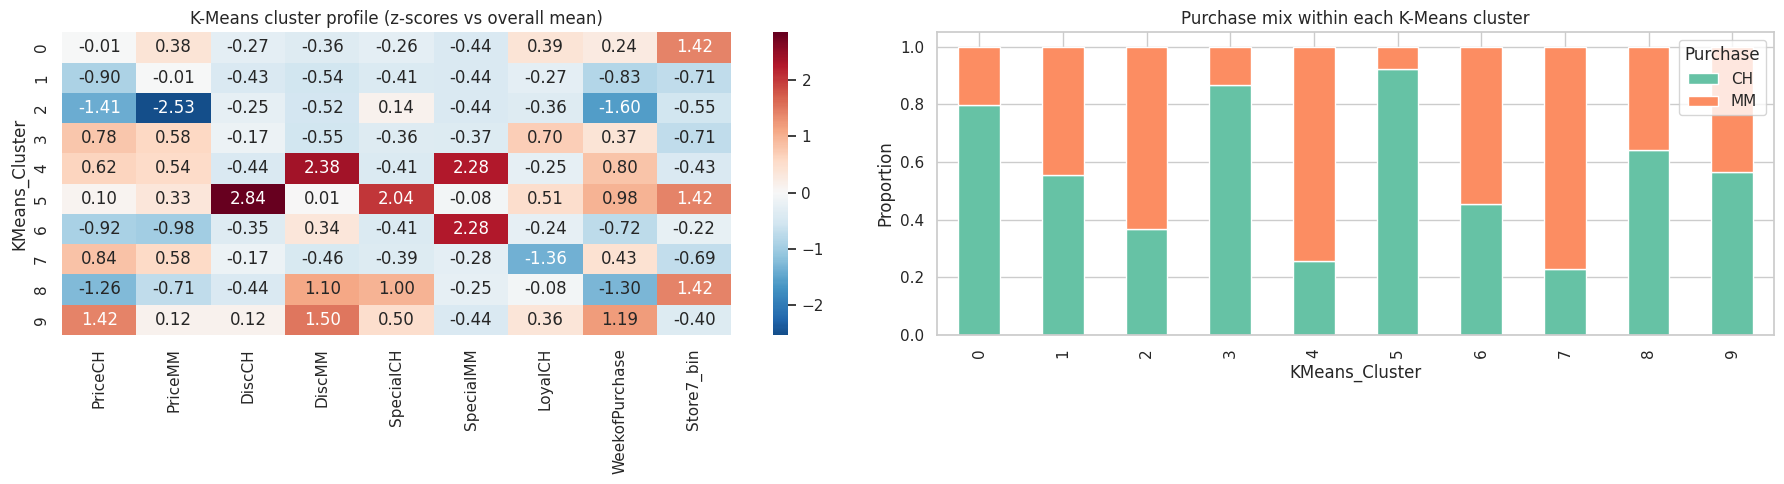

Crosstab K-Means cluster × Purchase:
Purchase         CH   MM   All
KMeans_Cluster                
0               133   34   167
1                84   67   151
2                30   52    82
3               172   26   198
4                18   52    70
5                84    7    91
6                34   41    75
7                27   91   118
8                36   20    56
9                35   27    62
All             653  417  1070


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
z_prof = (km_profile[cluster_features] - df[cluster_features].mean()) / df[cluster_features].std()
sns.heatmap(z_prof, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("K-Means cluster profile (z-scores vs overall mean)")
pd.crosstab(df["KMeans_Cluster"], df["Purchase"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Purchase mix within each K-Means cluster"); axes[1].set_ylabel("Proportion")
plt.tight_layout(); plt.show()

print("Crosstab K-Means cluster × Purchase:")
print(pd.crosstab(df["KMeans_Cluster"], df["Purchase"], margins=True))

## 8. Hierarchical (Agglomerative) Clustering

Cophenetic correlation (how faithfully the tree preserves pairwise distances):
average    0.8099
single     0.7455
ward       0.6916
complete   0.6214
dtype: float64


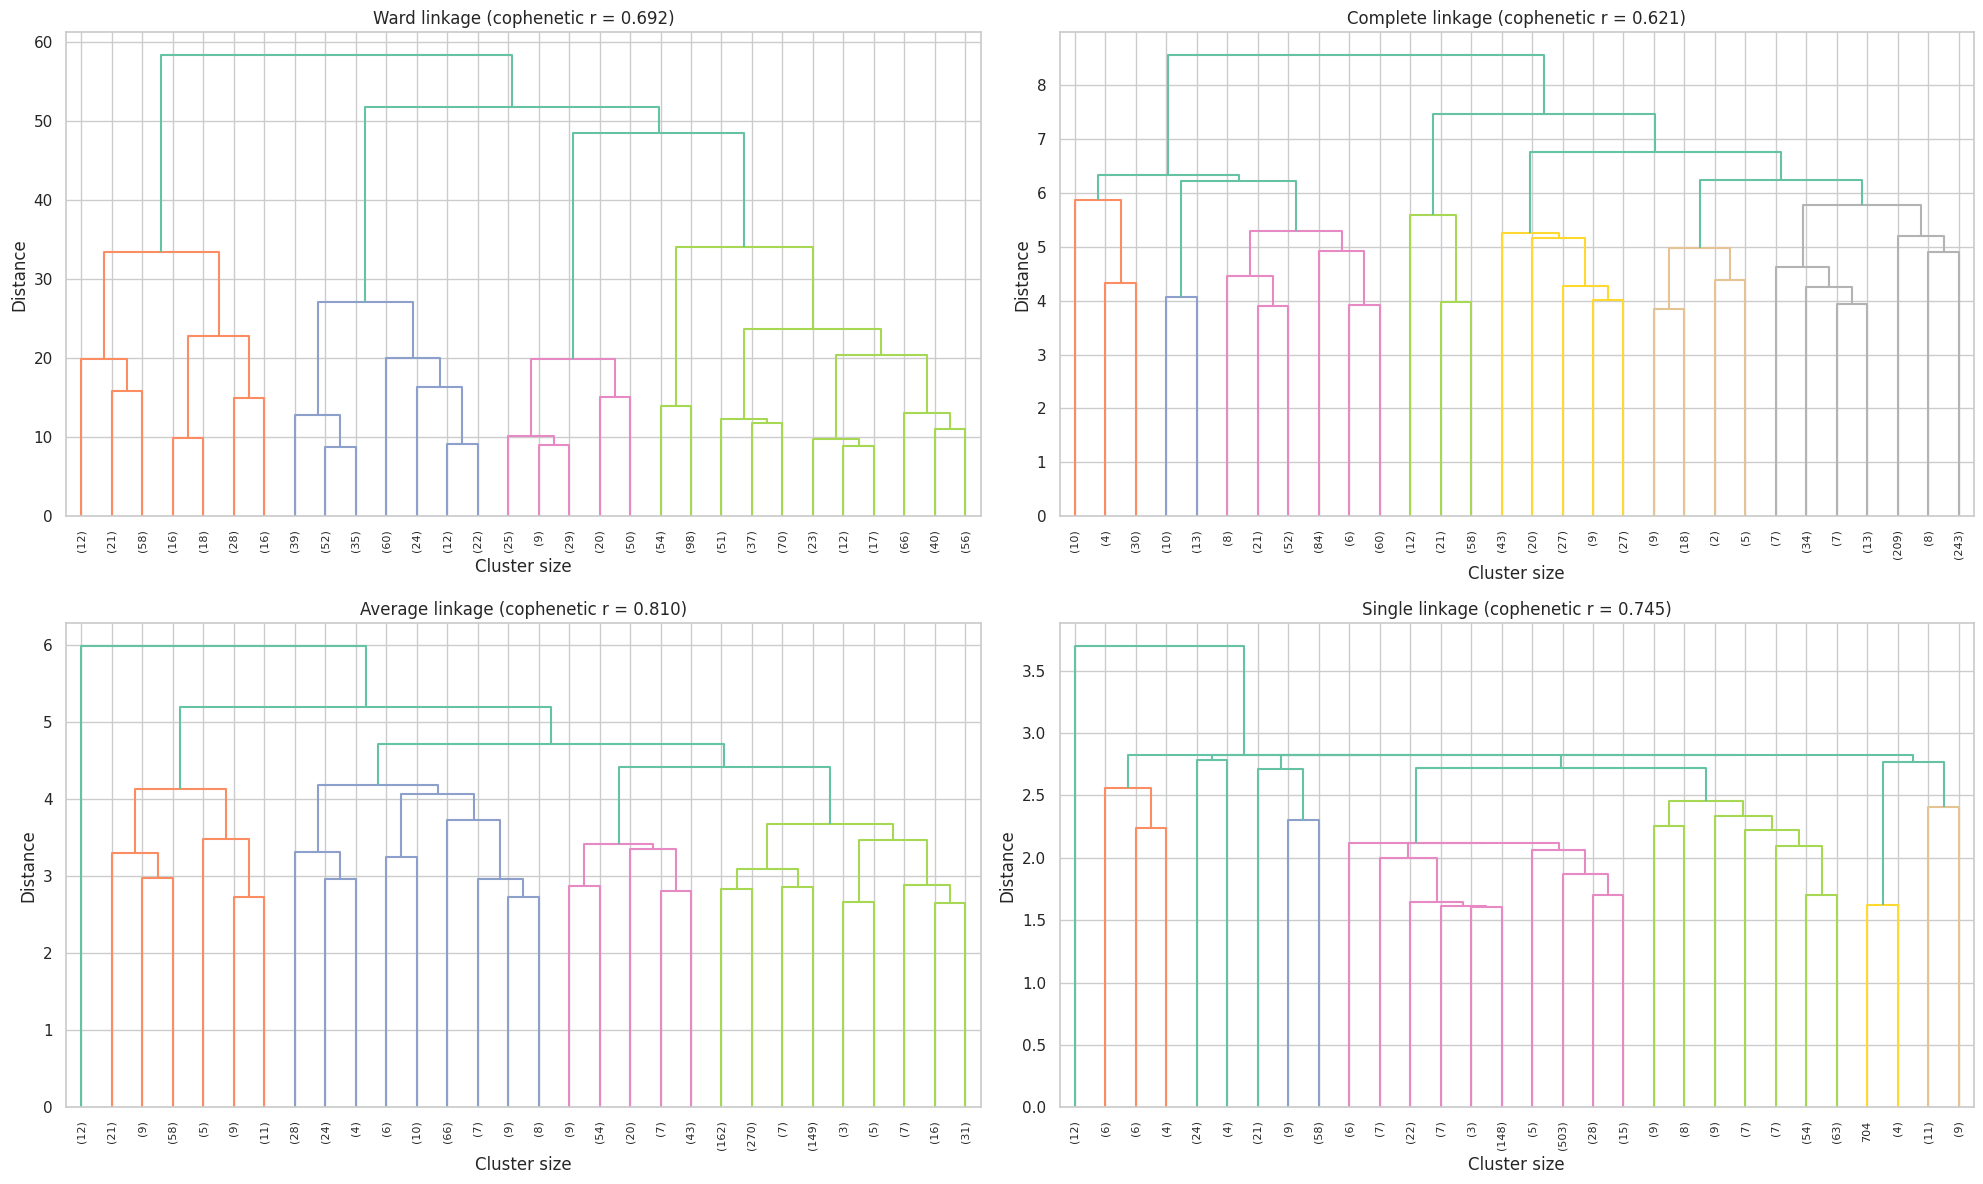

In [50]:
methods = ["ward", "complete", "average", "single"]
dist = pdist(X_scaled)
linkages, coph = {}, {}
for m in methods:
    linkages[m] = linkage(X_scaled, method=m)
    coph[m] = cophenet(linkages[m], dist)[0]
print("Cophenetic correlation (how faithfully the tree preserves pairwise distances):")
print(pd.Series(coph).round(4).sort_values(ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, m in zip(axes.ravel(), methods):
    dendrogram(linkages[m], truncate_mode="lastp", p=30, show_leaf_counts=True,
               leaf_rotation=90, leaf_font_size=8, ax=ax)
    ax.set_title(f"{m.capitalize()} linkage (cophenetic r = {coph[m]:.3f})")
    ax.set_xlabel("Cluster size"); ax.set_ylabel("Distance")
plt.tight_layout(); plt.show()

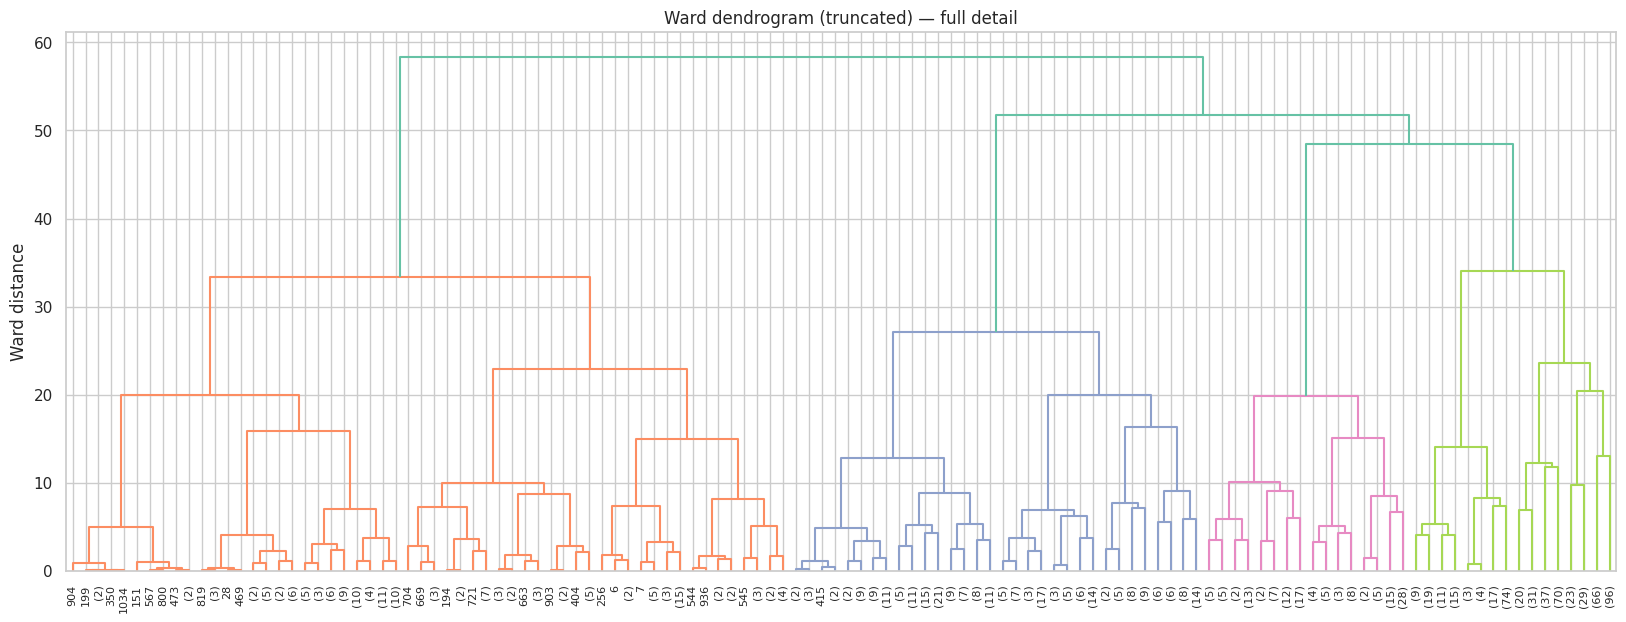

,clusters_after_cut,merge_distance,gap_to_next
0,2,58.3053,6.5783
1,3,51.7270,3.2543
2,4,48.4726,14.4671
3,5,34.0055,0.6260
4,6,33.3795,6.2364
5,7,27.1431,3.5162
6,8,23.6269,0.7659
7,9,22.8611,2.4252
8,10,20.4359,0.4531


In [51]:
Z = linkages["ward"]
plt.figure(figsize=(20, 7))
dendrogram(Z, truncate_mode="level", p=6, color_threshold=None, leaf_rotation=90, leaf_font_size=8)
last = Z[-10:, 2][::-1]
plt.title("Ward dendrogram (truncated) — full detail"); plt.ylabel("Ward distance")
plt.show()

# Largest jumps in merge distance suggest natural cut points
gaps = pd.DataFrame({"clusters_after_cut": range(2, 11), "merge_distance": last[:-1],
                     "gap_to_next": -np.diff(last)})
gaps

,silhouette,davies_bouldin,calinski_harabasz
k,,,
2,0.3094,1.5583,228.9127
3,0.2128,1.5620,245.8213
4,0.2579,1.3604,276.2844
5,0.2425,1.2458,263.5624
6,0.2733,1.2920,265.7396
7,0.2651,1.2804,258.7391
8,0.2593,1.3796,250.2318
9,0.2725,1.3459,245.9640
10,0.2780,1.2854,240.6120


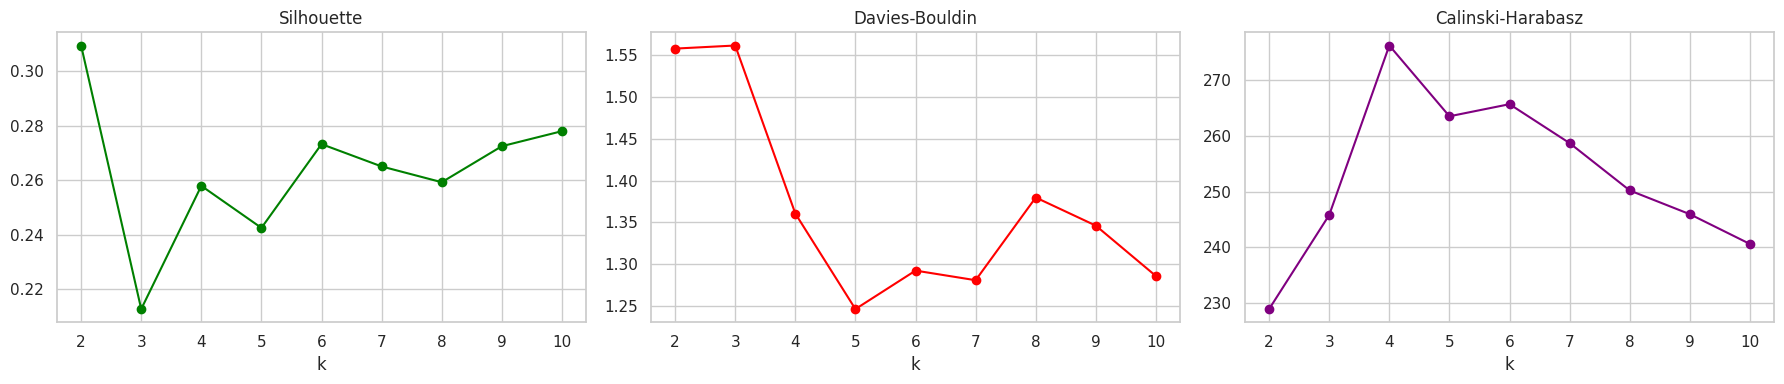

Best k (hierarchical, silhouette): 2


In [52]:
hc_metrics = []
for k in range(2, 11):
    lab = fcluster(Z, t=k, criterion="maxclust")
    hc_metrics.append({"k": k, "silhouette": silhouette_score(X_scaled, lab),
                       "davies_bouldin": davies_bouldin_score(X_scaled, lab),
                       "calinski_harabasz": calinski_harabasz_score(X_scaled, lab)})
hc_metrics = pd.DataFrame(hc_metrics).set_index("k")
display(hc_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
hc_metrics["silhouette"].plot(marker="o", color="green", ax=axes[0], title="Silhouette")
hc_metrics["davies_bouldin"].plot(marker="o", color="red", ax=axes[1], title="Davies-Bouldin")
hc_metrics["calinski_harabasz"].plot(marker="o", color="purple", ax=axes[2], title="Calinski-Harabasz")
plt.tight_layout(); plt.show()

best_k_hc = int(hc_metrics["silhouette"].idxmax())
print("Best k (hierarchical, silhouette):", best_k_hc)

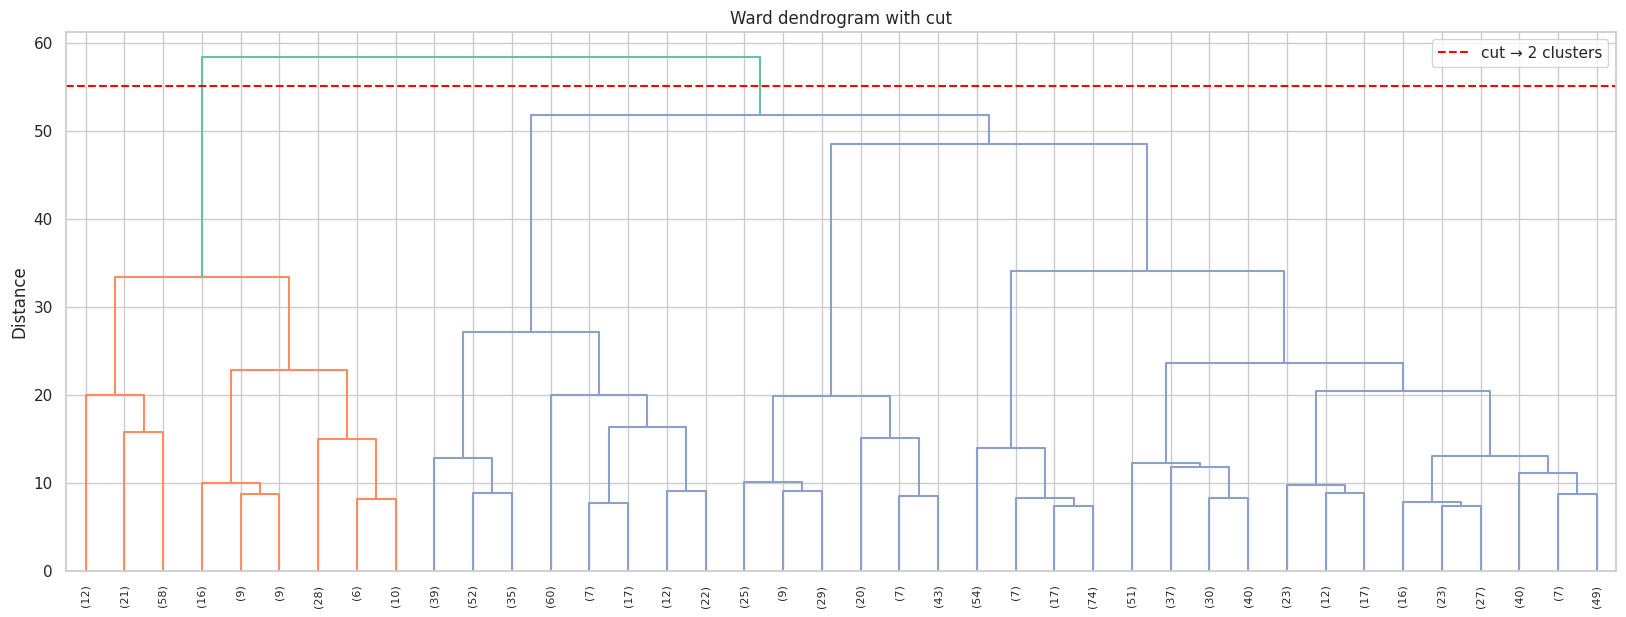

In [53]:
# Dendrogram with the chosen cut line
cut_height = (Z[-best_k_hc, 2] + Z[-best_k_hc + 1, 2]) / 2
plt.figure(figsize=(20, 7))
dendrogram(Z, truncate_mode="lastp", p=40, color_threshold=cut_height, leaf_rotation=90,
           leaf_font_size=8, show_leaf_counts=True)
plt.axhline(cut_height, color="red", ls="--", label=f"cut → {best_k_hc} clusters")
plt.title("Ward dendrogram with cut"); plt.ylabel("Distance"); plt.legend(); plt.show()

In [54]:
agg = AgglomerativeClustering(n_clusters=best_k_hc, linkage="ward")
df["HC_Cluster"] = agg.fit_predict(X_scaled)

print("Cluster sizes:"); print(df["HC_Cluster"].value_counts().sort_index())
print(f"\nSilhouette: {silhouette_score(X_scaled, df['HC_Cluster']):.3f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, df['HC_Cluster']):.3f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(X_scaled, df['HC_Cluster']):.1f}")

Cluster sizes:
HC_Cluster
0    901
1    169
Name: count, dtype: int64

Silhouette: 0.309
Davies-Bouldin: 1.558
Calinski-Harabasz: 228.9


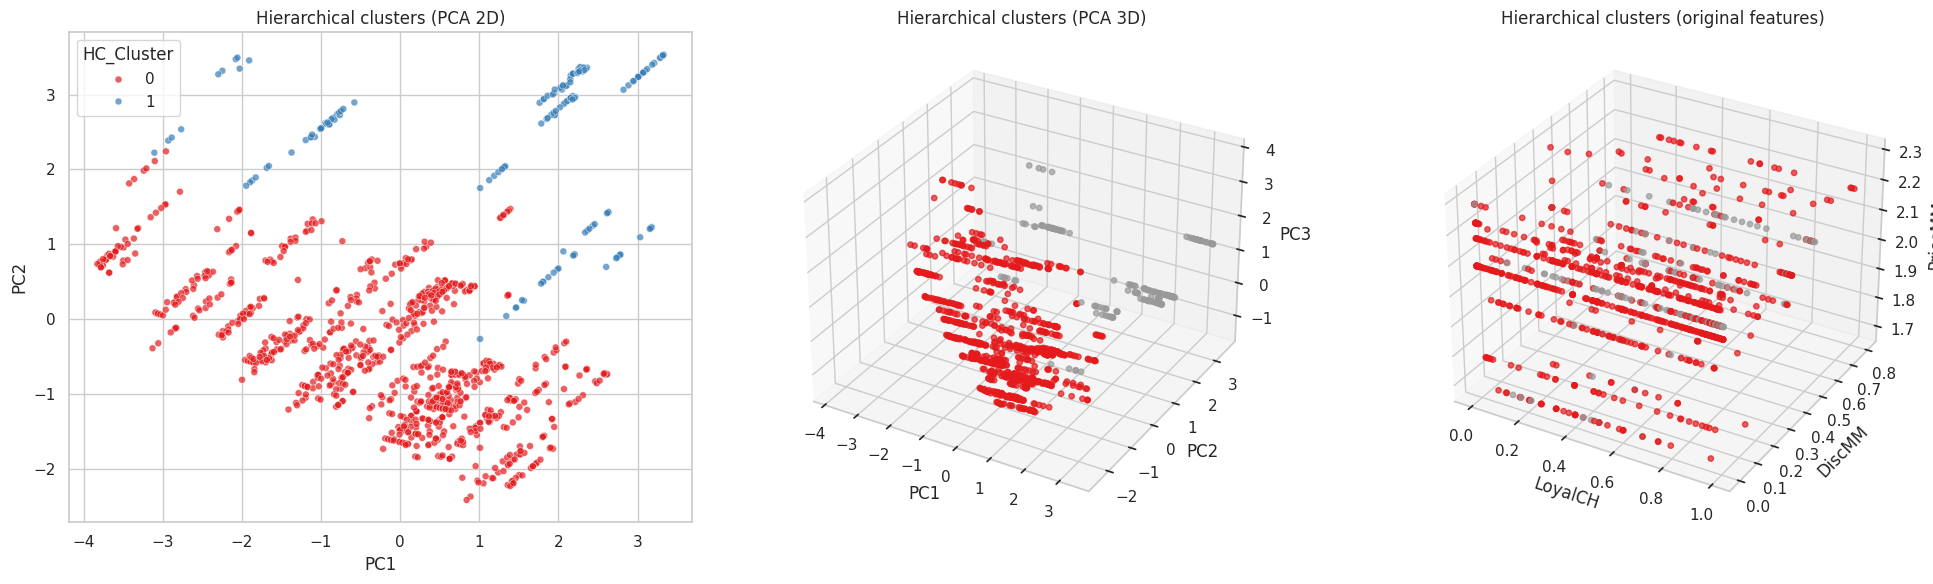

In [55]:
fig = plt.figure(figsize=(20, 6))
ax1 = fig.add_subplot(131)
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=df["HC_Cluster"], palette="Set1", s=25, alpha=0.7, ax=ax1)
ax1.set_title("Hierarchical clusters (PCA 2D)"); ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=df["HC_Cluster"], cmap="Set1", s=15, alpha=0.7)
ax2.set_title("Hierarchical clusters (PCA 3D)"); ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(df["LoyalCH"], df["DiscMM"], df["PriceMM"], c=df["HC_Cluster"], cmap="Set1", s=15, alpha=0.7)
ax3.set_xlabel("LoyalCH"); ax3.set_ylabel("DiscMM"); ax3.set_zlabel("PriceMM")
ax3.set_title("Hierarchical clusters (original features)")
plt.tight_layout(); plt.show()

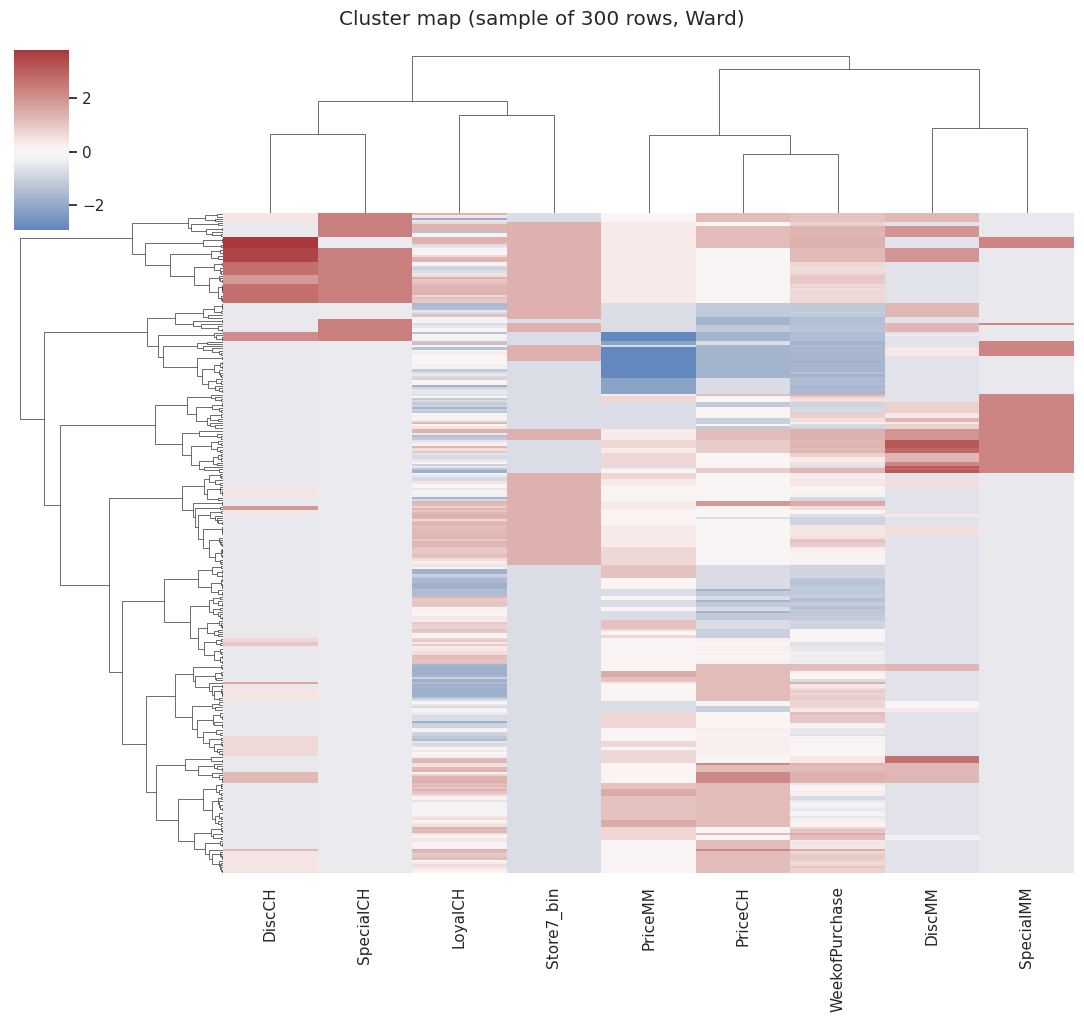

In [56]:
# Clustered heatmap: rows (samples) and columns (features) both hierarchically ordered
g = sns.clustermap(pd.DataFrame(X_scaled, columns=cluster_features).sample(min(300, len(df)), random_state=RANDOM_STATE),
                   method="ward", cmap="vlag", center=0, figsize=(11, 10), yticklabels=False)
g.fig.suptitle("Cluster map (sample of 300 rows, Ward)", y=1.02); plt.show()

,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,WeekofPurchase,Store7_bin,SalePriceCH,SalePriceMM,PriceDiff,size,MM_share_%
HC_Cluster,,,,,,,,,,,,,,
0,1.8700,2.0860,0.0190,0.1100,0.0000,0.1740,0.5470,253.3730,0.2430,1.8510,1.9770,0.1250,901,41.8420
1,1.8530,2.0780,0.2250,0.1910,0.9290,0.0950,0.6630,259.7570,0.8110,1.6280,1.8870,0.2600,169,23.6690


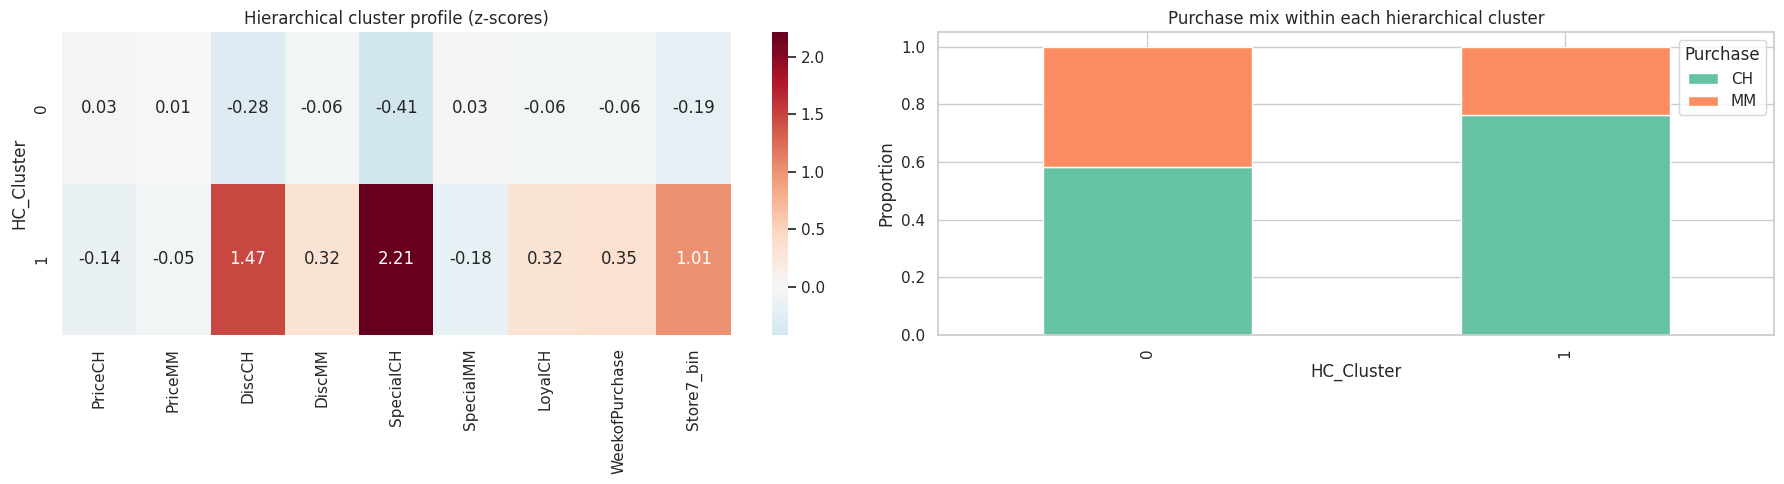

In [57]:
hc_profile = df.groupby("HC_Cluster")[profile_cols].mean()
hc_profile["size"] = df["HC_Cluster"].value_counts().sort_index()
hc_profile["MM_share_%"] = df.groupby("HC_Cluster")["Purchase_bin"].mean() * 100
display(hc_profile.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
z_hc = (hc_profile[cluster_features] - df[cluster_features].mean()) / df[cluster_features].std()
sns.heatmap(z_hc, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Hierarchical cluster profile (z-scores)")
pd.crosstab(df["HC_Cluster"], df["Purchase"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Purchase mix within each hierarchical cluster"); axes[1].set_ylabel("Proportion")
plt.tight_layout(); plt.show()

## 9. K-Means vs Hierarchical — Comparison

,K-Means,Hierarchical (Ward)
k,10.0000,2.0000
Silhouette (↑),0.3115,0.3094
Davies-Bouldin (↓),1.1502,1.5583
Calinski-Harabasz (↑),265.2680,228.9127
ARI vs Purchase label,0.0606,-0.0208


Agreement between the two methods (Adjusted Rand Index): 0.067


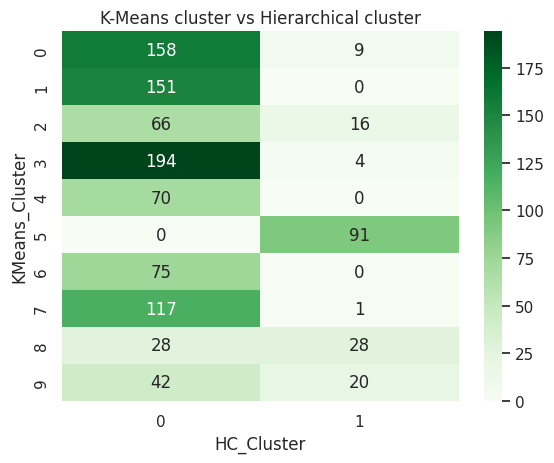

In [58]:
comparison = pd.DataFrame({
    "K-Means": [best_k,
                silhouette_score(X_scaled, df["KMeans_Cluster"]),
                davies_bouldin_score(X_scaled, df["KMeans_Cluster"]),
                calinski_harabasz_score(X_scaled, df["KMeans_Cluster"]),
                adjusted_rand_score(df["Purchase"], df["KMeans_Cluster"])],
    "Hierarchical (Ward)": [best_k_hc,
                silhouette_score(X_scaled, df["HC_Cluster"]),
                davies_bouldin_score(X_scaled, df["HC_Cluster"]),
                calinski_harabasz_score(X_scaled, df["HC_Cluster"]),
                adjusted_rand_score(df["Purchase"], df["HC_Cluster"])],
}, index=["k", "Silhouette (↑)", "Davies-Bouldin (↓)", "Calinski-Harabasz (↑)", "ARI vs Purchase label"])
display(comparison.round(4))

print(f"Agreement between the two methods (Adjusted Rand Index): "
      f"{adjusted_rand_score(df['KMeans_Cluster'], df['HC_Cluster']):.3f}")
ct = pd.crosstab(df["KMeans_Cluster"], df["HC_Cluster"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Greens")
plt.title("K-Means cluster vs Hierarchical cluster"); plt.xlabel("HC_Cluster"); plt.ylabel("KMeans_Cluster")
plt.show()

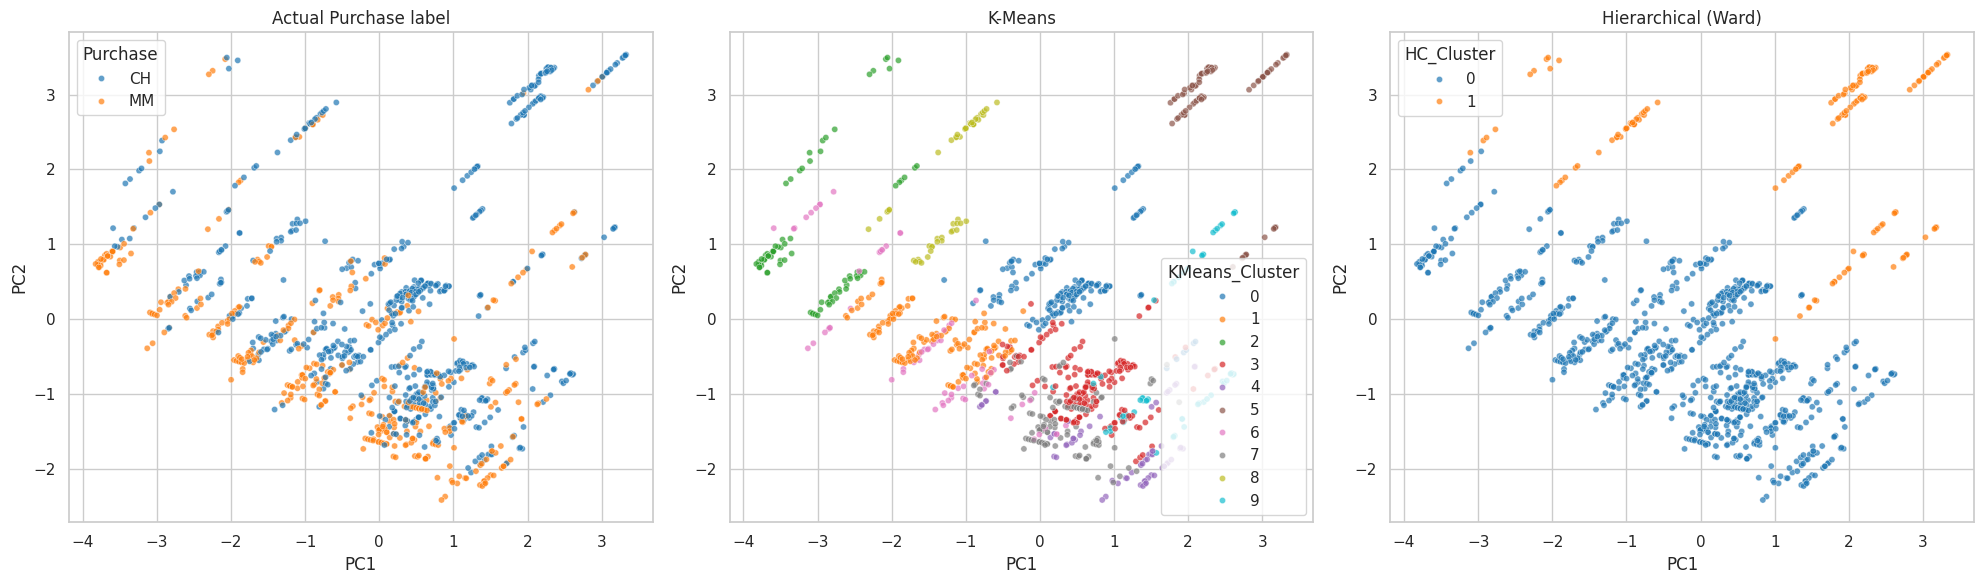

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (lab, title) in zip(axes, [(df["Purchase"], "Actual Purchase label"),
                                   (df["KMeans_Cluster"], "K-Means"),
                                   (df["HC_Cluster"], "Hierarchical (Ward)")]):
    sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=lab, palette="tab10", s=20, alpha=0.7, ax=ax)
    ax.set_title(title); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

In [60]:
# Save the dataset with cluster labels
df.to_csv("orange_juice_clustered.csv", index=False)
print("Saved: orange_juice_clustered.csv")

Saved: orange_juice_clustered.csv
